## 🇰🇷-🇺🇸 한영 기계 번역 모델 구축 가이드라인

### 1. 데이터 전처리

* **데이터셋 개수 변경**: 물론, 5~6만개만 사용하더라도, 학습 시간이 1시간 반 정도 소요될 수 있으므로, 적당히 사용할 것을 권장합니다.

* **문장 분석 및 설정:** 

    * 전체 데이터의 문장 길이를 분석하여 최적의 **MAX_LENGTH**를 설정합니다.

        * 문장 길이에 따른 분포 확인 및 이상치 판단 및 제거 근거 만들어보세요

* **토큰화:** 한국어와 영어 특성에 맞는 적절한 토크나이저를 선택하여 문장을 토큰 단위로 분리합니다.

    * 토큰화 종류 선택하기

        1. 형태소 토큰화

        2. 서브워드 토큰화 : vocab_size 하이퍼 파라미터 실험 및 토큰 단위의 의미 확인해보기

    * 학습에 필수적인 특수 토큰(`SOS`, `EOS`, `PAD`, `UNK`)을 정의합니다.

### 2. 어휘 사전 구축

* **사전 구성:** 한국어와 영어 각각의 독립적인 어휘 사전을 생성합니다.

* **빈도수 관리:** 단어의 등장 빈도를 고려하여 어휘 크기를 조정하고, 이를 임베딩 및 모델 구성에 반영합니다.

### 3. 텐서 변환 및 데이터 로더 구현

* **인덱싱 및 패딩:** 토큰 시퀀스를 인덱스 시퀀스로 변환하고, `PAD` 토큰을 사용해 고정 길이로 맞춥니다.

* **효율적 처리:** `TensorDataset`과 `DataLoader`를 활용하여 배치(Batch) 단위의 효율적인 학습 파이프라인을 구축합니다.

### 4. 모델 구현 및 학습

#### Seq2Seq 모델

* 기본 **GRU 기반**의 Encoder-Decoder 구조를 설계합니다.

    * 단방향 vs 양방향

* 학습 속도 향상을 위해 **Teacher Forcing** 기법을 적용합니다.

#### Attention 모델

* **Bahdanau** 또는 **Luong Attention**을 디코더에 적용하여 문맥 정보 활용 능력을 높이고 번역 성능을 개선합니다.

### 5. 모델 학습 및 평가

* **학습 진행:** 각 모델별로 학습을 수행하며 손실(Loss) 변화를 모니터링합니다.

    * Early Stopping 적용해보기

    * teacher forcing이 과적합 요인될 수 있으므로, 적용 확률을 조절해보기

* **결과 검증:** 평가 함수를 통해 무작위 문장 쌍의 번역 결과를 확인합니다.

* **후처리:** 출력 문장에서 특수 토큰을 제거하고 텍스트를 정제하여 최종 성능을 분석합니다.

### 6. 추가 실험 (선택 사항)

* **전처리 개선:** 불용어 제거, 데이터 정규화 등 고도화된 전처리 적용.

* **구조 변경:** 레이어 수(Num Layers), 은닉 상태(Hidden Size) 크기 조정 및 Attention 메커니즘 수정.

* **튜닝:** 학습률(Learning Rate), 배치 크기(Batch Size) 등 하이퍼파라미터 최적화.

* **평가 지표:** **BLEU 점수**와 같은 정량적 지표를 도입하여 객관적 성능 측정.


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
!apt-get install -y mecab mecab-ipadic-utf8 libmecab-dev
!pip install konlpy
!pip install kiwipiepy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libmecab-dev is already the newest version (0.996-14build9).
mecab-ipadic-utf8 is already the newest version (2.7.0-20070801+main-3).
mecab is already the newest version (0.996-14build9).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 30.2 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 159.6 MB/s eta 0:00:0000:01
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=f40126ecac023fb928dd9206b83f48646265f136341e20f080c26de9010cbdce
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model


- 여러분 다운로드 받은 데이터셋 파일을 구글 드라이브 data 폴더에 넣어주세요!

    - 한글명은 오류를 발생시킬 수 있으므로, 아래와 같이 변경하도록 하겠습니다.

        > `일상생활및구어체_한영` $\to$ `casual_speech_corpus_ko_en` 

In [6]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, RandomSampler
from konlpy.tag import Okt
import nltk
from nltk.tokenize import word_tokenize
from kiwipiepy import Kiwi

nltk.download('punkt')
nltk.download('punkt_tab')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# JSON 파일 경로(구글 드라이브 data 폴더에 넣어놨다고 가정)
train_json_file_path = "/content/drive/MyDrive/data/casual_speech_corpus_ko_en/casual_speech_corpus_ko_en_train_set.json"
valid_json_file_path = "/content/drive/MyDrive/data/casual_speech_corpus_ko_en/casual_speech_corpus_ko_en_valid_set.json"

# JSON 파일 불러오기
def load_json(file_path, max_samples=1000):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data["data"][:max_samples]

# 훈련 및 검증 데이터 로드
data_train = load_json(train_json_file_path, max_samples=50000)
data_valid = load_json(valid_json_file_path, max_samples=1000)

print(f"훈련 데이터 샘플 수: {len(data_train)}")
print(f"검증 데이터 샘플 수: {len(data_valid)}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


훈련 데이터 샘플 수: 50000
검증 데이터 샘플 수: 1000


- konlpy 대신 kiwi tokenizer 사용 가능

In [ ]:
# ko와 mt 데이터 추출
ko_sentences_train = [item["ko"] for item in data_train]
mt_sentences_train = [item["mt"] for item in data_train]
ko_sentences_valid = [item["ko"] for item in data_valid]
mt_sentences_valid = [item["mt"] for item in data_valid]

# 한국어 및 영어 토크나이저
# tokenizer_ko = Okt().morphs # konlpy 대신 kiwi tokenizer 사용 가능

# 1. Kiwi 형태소 분석기 초기화
kiwi = Kiwi()

# 2. 한국어 토크나이저 함수 정의 (Kiwipiepy 활용)
def tokenizer_ko(text):
    # kiwi.tokenize 결과에서 형태소 텍스트(form)만 리스트로 반환
    return [token.form for token in kiwi.tokenize(text)]

tokenizer_en = word_tokenize

## 문장 길이 분석
ko_lengths = [len(tokenizer_ko(sent)) for sent in ko_sentences_train]
en_lengths = [len(tokenizer_en(sent)) for sent in mt_sentences_train]
all_lengths = ko_lengths + en_lengths

# 한국어와 영어 중 가장 긴 문장의 길이 기준으로 MAX_LENGTH 설정
MAX_LENGTH = max(max(ko_lengths), max(en_lengths)) + 1  # SOS, EOS 포함 고려
print(f"한국어 문장 최대 길이: {ko_lengths[:10]} ... {max(ko_lengths)}")
print(f"영어 문장 최대 길이: {en_lengths[:10]} ... {max(en_lengths)}")
print(f"Max sequence length: {MAX_LENGTH}")

한국어 문장 최대 길이: [18, 13, 4, 10, 20, 5, 10, 8, 18, 27] ... 123
영어 문장 최대 길이: [17, 8, 2, 15, 14, 7, 7, 8, 14, 16] ... 68
Max sequence length: 124


In [ ]:
# 특수 토큰 정의
SOS_token = 0 # Start of Sentence
EOS_token = 1 # End of Sentence
PAD_token = 2 # Padding
UNK_token = 3 # token to represent unknown words

class Lang:
    def __init__(self, name):
        self.name = name
        # 초기에는 PAD, SOS, EOS, UNK 토큰을 미리 등록
        # self.word2index = {PAD_token: "PAD", SOS_token: "SOS", EOS_token: "EOS", UNK_token: "<unk>"}
        self.word2index = {
            "SOS": SOS_token, 
            "EOS": EOS_token, 
            "PAD": PAD_token, 
            "<unk>": UNK_token
        }
        self.index2word = {
            SOS_token: "SOS", 
            EOS_token: "EOS", 
            PAD_token: "PAD", 
            UNK_token: "<unk>"
        }
        self.word2count = {"SOS": 0, "EOS": 0, "PAD": 0, "<unk>": 0}
        self.n_words = 4  # PAD, SOS, EOS, UNK 포함

    def addSentence(self, sentence, tokenizer): # tokenizer 인자 추가
        for word in tokenizer(sentence):
            self.addWord(word)

    def addWord(self, word): # 단어가 처음 등장하면 word2index와 index2word에 등록, 등장 횟수 초기화
        if word not in self.word2index:
            # print(f"새 단어 등록: '{word}' with index {self.n_words}")
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word2count[word] = 1
            self.n_words += 1
        else:
            self.word2count[word] += 1

# 데이터 준비
def prepareData(lang1, lang2, tokenizer1, tokenizer2):
    input_lang = Lang(lang1)
    output_lang = Lang(lang2)
    pairs = list(zip(ko_sentences_train, mt_sentences_train)) # 훈련 데이터에서 ko와 mt 문장 쌍 생성
    # print(f"데이터 샘플 5개 확인: {pairs[:5]}") # 데이터 샘플 확인
    print("Read %s sentence pairs" % len(pairs))
    for pair in pairs:
        input_lang.addSentence(pair[0], tokenizer1) # tokenizer1 인자 추가
        output_lang.addSentence(pair[1], tokenizer2) # tokenizer2 인자 추가
    return input_lang, output_lang, pairs

# pairs는 pairs_train이랑 동일함.
input_lang, output_lang, pairs = prepareData("ko", "en", tokenizer_ko, tokenizer_en)

# 텐서 변환 및 데이터 로더 생성
def tensorFromSentence(lang, sentence, tokenizer):
    indexes = [SOS_token]
    indexes += [lang.word2index.get(word, UNK_token) for word in tokenizer(sentence)[:MAX_LENGTH - 2]]
    indexes.append(EOS_token)
    # 길이 MAX_LENGTH에 맞춰 PAD 추가
    while len(indexes) < MAX_LENGTH:
        indexes.append(PAD_token)
    return torch.tensor(indexes[:MAX_LENGTH], dtype=torch.long, device=device)

# 텐서 변환 및 데이터 로더 생성
def get_dataloader(batch_size):
    input_tensors = [tensorFromSentence(input_lang, inp, tokenizer_ko) for inp, _ in pairs]
    target_tensors = [tensorFromSentence(output_lang, tgt, tokenizer_en) for _, tgt in pairs]

    input_tensors = torch.stack(input_tensors, dim=0)  # [num_samples, MAX_LENGTH]
    target_tensors = torch.stack(target_tensors, dim=0)  # [num_samples, MAX_LENGTH]

    dataset = TensorDataset(input_tensors, target_tensors)
    train_sampler = RandomSampler(dataset)
    train_dataloader = DataLoader(dataset, sampler=train_sampler, batch_size=batch_size)

    print(f"input_tensors.shape([num_samples, MAX_LENGTH]): {input_tensors.shape}, target_tensors.shape([num_samples, MAX_LENGTH]): {target_tensors.shape}")
    return train_dataloader

train_dataloader = get_dataloader(batch_size=32)

[('원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.', 'If you reply to the color you want, we will start making it right away.'), ('형님 제일 웃긴 그림이 뭔지 알아요.', 'I know what the funniest picture is.'), ('>속옷을?', 'Underwear?'), ('그래도 가격이 꽤 비싸니까 많이 살게요.', 'However, the price is quite high, so I will buy a lot.'), ('AAA님, 제가 회의에서 화를 냈던 점 정말 사과드리고 싶습니다.', 'AAA, I really want to apologize for being upset at the meeting.')]
Read 50000 sentence pairs
input_tensors.shape([num_samples, MAX_LENGTH]): torch.Size([50000, 124]), target_tensors.shape([num_samples, MAX_LENGTH]): torch.Size([50000, 124])



#### 현재 데이터 상태 요약
| 구분 | 내용 | 비고 |
| :--- | :--- | :--- |
| **샘플 수** | 50,000개 | 한국어 5만 문장, 영어 5만 문장 |
| **문장 최대 길이** | 124 | SOS, EOS 토큰 포함 수치 |
| **Batch Size** | 32 | `get_dataloader(batch_size=32)` 설정 기준 |
| **총 스텝(Step)** | 약 1,563번 | 50,000 / 32 (1 Epoch당 업데이트 횟수) |



In [17]:
# 샘플 문장
print(ko_sentences_train[0])
print(mt_sentences_train[0])

원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.
If you reply to the color you want, we will start making it right away.


- pairs는 pairs_train이랑 동일함.

In [ ]:
# 학습 및 검증 데이터를 위한 pair 생성 및 확인
pairs_valid = list(zip(ko_sentences_valid, mt_sentences_valid))
print("Read %s validation sentence pairs" % len(pairs_valid))
print("Read %s training sentence pairs" % len(pairs))

Read 1000 validation sentence pairs
Read 50000 training sentence pairs


# Seq2Seq

In [ ]:
import torch.nn.functional as F

# Encoder 정의
class EncoderRNN(nn.Module):
    """
    Encoder 정의: 입력 문장을 읽어 문맥 벡터(Context Vector)를 생성
    """
    
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size # 

        # 입력을 임베딩 벡터로 변환 (Vocab Size -> Embedding Dim)
        self.embedding = nn.Embedding(input_size, hidden_size) 
        # GRU 레이어 (입력 차원, 은닉 차원)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        # 과적합 방지를 위한 Dropout
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        """ 
        output: 모든 시점(Time-step)의 hidden state
        hidden: 마지막 시점의 hidden state (디코더의 초기 입력값으로 사용됨)
        """

        # input: [batch_size, seq_len]
        embedded = self.dropout(self.embedding(input))
        # embedded: [batch_size, seq_len, hidden_size]
        
        output, hidden = self.gru(embedded)
        # output: [batch_size, seq_len, hidden_size]
        # hidden: [1, batch_size, hidden_size]
        
        return output, hidden 

# Decoder 정의
class DecoderRNN(nn.Module):
    """
    Decoder 정의: Encoder의 정보를 받아 타겟 문장을 한 단어씩 생성
    """
    
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size) # 최종 단어 예측을 위한 선형 레이어

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        # 초기 디코더 입력: 배치 크기만큼의 SOS_token 생성 ([batch_size, 1])
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=encoder_outputs.device).fill_(SOS_token)
        # 인코더의 마지막 hidden state를 디코더의 첫 번째 hidden state로 전달
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        # 최대 문장 길이(MAX_LENGTH)만큼 루프를 돌며 단어 생성
        for i in range(MAX_LENGTH):
            
            # 한 스텝씩 단어 예측
            decoder_output, decoder_hidden = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                """
                Teacher forcing: 학습 중 실제 정답(Ground Truth)을 다음 입력으로 사용
                """
                # target_tensor[:, i]: 모든 배치의 i번째 단어 추출 -> [batch_size, 1]
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                """
                Inference(추론) 단계: 모델이 방금 예측한 단어(Top-1)를 다음 입력으로 사용
                """
                # 모델 예측: topk 결과에서 가장 높은 확률을 가진 토큰 선택
                _, topi = decoder_output.topk(1)
                # topi의 shape: [batch_size, 1, 1] → squeeze 마지막 차원만 제거하여 [batch_size, 1]
                decoder_input = topi.squeeze(2).detach()

        # 모든 스텝의 출력을 결합: [batch_size, MAX_LENGTH, output_size]
        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        # 손실 함수 계산을 위해 로그 소프트맥스 적용
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None

    def forward_step(self, input, hidden):
        """
        forward_step 함수는 디코더가 한 시점에서 단어를 예측하는 과정을 수행합니다. (forward 함수 내에서 반복적으로 호출됩니다.)
        """
        
        # input: 현재 시점의 입력 단어 인덱스 [batch_size, 1]
        output = self.embedding(input)          # → [batch_size, 1, hidden_size]
        output = F.relu(output)                 # 비선형 활성화 함수 적용
        output, hidden = self.gru(output, hidden) # # GRU를 거쳐 은닉 상태 업데이트: [batch_size, 1, hidden_size]
        output = self.out(output)                 # 단어별 확률(Logit) 계산 [batch_size, 1, output_size]
        return output, hidden


In [ ]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer,
                decoder_optimizer, criterion):
    # 모델을 학습 모드로 설정 (Dropout, Batch Normalization 등이 활성화됨)
    encoder.train()
    decoder.train()

    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        # GPU/CPU 장치로 데이터 이동 및 데이터 타입(Long) 확인
        input_tensor = input_tensor.long().to(device)
        target_tensor = target_tensor.long().to(device)

        # 이전 스텝의 기울기(gradient) 초기화
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        # 1. 인코더 통과: 문맥 벡터(hidden)와 모든 시점의 출력(outputs) 획득
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        
        # 2. 디코더 통과: 인코더 hidden과 정답지(target_tensor)를 넣어 예측값 획득
        # 여기서 target_tensor는 Teacher Forcing을 위해 사용됨
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        # 3. 손실(Loss) 계산
        # view(-1, 클래스수)를 통해 3차원 출력을 2차원으로 펼쳐 NLLLoss 규격에 맞춤
        # target_tensor 역시 1차원으로 펼쳐 각 단어별 손실을 계산
        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        
        # 4. 역전파: 기울기 계산
        loss.backward()

        # 5. 가중치 업데이트
        encoder_optimizer.step()
        decoder_optimizer.step()

        # 오차 누적 (나중에 평균을 내기 위함)
        total_loss += loss.item()

    return total_loss / len(dataloader)

def train_seq2seq(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001, print_every=100):
    print_loss_total = 0  

    # 최적화 알고리즘 설정: 주로 성능이 좋은 Adam 사용
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    
    # 손실 함수: Decoder의 끝에 LogSoftmax가 있으므로 Negative Log Likelihood Loss 사용
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        # 한 에폭 학습 수행
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)

        # 지정된 주기마다 현재 오차(Loss) 출력
        if epoch % print_every == 0:
            print(f"Epoch {epoch}/{n_epochs}, Loss: {loss:.4f}")

- 여러분 학습이 오래 걸리기 때문에, 충분히 시간을 두고 학습을 진행해주세요!

    - L4 GPU 기준 약 1epoch당 4분의 시간이 소요

In [ ]:
# 모델 초기화 및 학습 실행
hidden_size = 128
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = DecoderRNN(hidden_size, output_lang.n_words).to(device)

train_seq2seq(train_dataloader, encoder, decoder, n_epochs=30, print_every=1)

In [ ]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    # 모델을 평가 모드로 전환 (Dropout 등의 기능 비활성화)
    encoder.eval()
    decoder.eval()

    # 기울기 계산을 하지 않음으로써 메모리 절약 및 연산 속도 향상
    with torch.no_grad():
        # 1. 입력 문장을 텐서로 변환 후 배치 차원 추가 [1, MAX_LENGTH]
        input_tensor = tensorFromSentence(input_lang, sentence, tokenizer_ko).unsqueeze(0)
        
        # 2. 인코더에 입력하여 문맥 정보(hidden) 추출
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        
        # 3. 디코더를 통해 번역 문장 생성
        # 디코더는 인코더의 마지막 hidden state를 초기 입력으로 사용함 (sequence-to-sequence 모델의 일반적인 구조)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        # 4. 각 시점(Time-step)에서 확률이 가장 높은 단어 인덱스 추출
        # decoder_outputs: [1, MAX_LENGTH, output_size] -> topk(1)은 가장 큰 값 1개 선택
        _, topi = decoder_outputs.topk(1)
        # 차원 축소: [MAX_LENGTH] 형태의 인덱스 리스트로 변환
        decoded_ids = topi.squeeze()

        decoded_words = []
        # 5. 인덱스를 실제 단어로 변환
        for idx in decoded_ids:
            if idx.item() == EOS_token: # 문장 끝 토큰을 만나면 멈춤
                decoded_words.append('<EOS>')
                break
            # 숫자를 다시 단어로 변환하여 리스트에 추가
            decoded_words.append(output_lang.index2word[idx.item()])
            
    return decoded_words, decoder_attn

def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        # 1. 전체 쌍(pairs) 중에서 무작위로 하나 선택
        pair = random.choice(pairs)
        print('>', pair[0]) # 입력된 한국어 문장
        print('=', pair[1]) # 실제 정답 영어 문장

        # 2. evaluate 함수를 호출하여 모델의 예측 결과 획득
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)

        # 3. 출력 결과에서 특수 토큰(<SOS>, <EOS> 등)을 제거하여 가독성 높임
        tokens_to_remove = ['<SOS>', 'SOS', '<EOS>', 'EOS']
        output_words = [w for w in output_words if w not in tokens_to_remove]

        # 4. 단어 리스트를 하나의 문장 문자열로 합침
        output_sentence = ' '.join(output_words)
        print('<', output_sentence) # 모델이 생성한 번역 문장
        print('') # 문장 간 구분을 위한 줄바꿈

- 입력 문장(>), 정답 문장(=), 모델이 예측한 문장(<)

In [ ]:
evaluateRandomly(encoder, decoder)

> 이 메일이 귀하께 잘 도착했기를 바랍니다.
= I hope this mail has arrived well for you.
< I hope you will receive the product as soon as possible .

> 이 건 만큼은 제가 계속 체크하여 직접 연락드리도록 하겠습니다.
= I'll keep checking this and contact you directly.
< We will contact you again after arranging a few days .

> 제가 한번 오피스텔을 보러 가도 될까요?
= Can I go see the officetel?
< Can I get a chance to see ?

> 저희는 오랜 연구 끝에 피토알렉신을 함유한 콩 추출물이 피부 보호 능력에 뛰어남을 발견했습니다.
= After a long study, we found that soybean extracts containing phyto-Alexin are excellent in skin protection.
< It contains adenosine and niacinamide to brighten the dark and soft texture to the taste of the cold .

> 커버는 탈부착과 세척이 가능하여 청소하기 쉽습니다.
= The cover is removable and washable, making it easy to clean.
< It is easy to carry in the form of three-piece water .

> 그리고 우유를 조금 넣어야지 안 그러면 퍽퍽해서 살리지가 않아서 한 이 정도만 넣고 설탕 두 숟갈 정도.
= And if you don't add a little milk, it's dry and doesn't save it, so add about this much and about two spoons of sugar.
< And if you have a small

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculate_bleu_score(encoder, decoder, evaluation_pairs, input_lang, output_lang):
    encoder.eval()
    decoder.eval()
    
    total_bleu = 0
    # 스무딩 함수: 아주 짧은 문장에서 n-gram이 일치하지 않아 점수가 0이 되는 것을 방지
    smoothie = SmoothingFunction().method1
    
    print(f"Calculating BLEU for {len(evaluation_pairs)} pairs...")

    with torch.no_grad():
        for pair in evaluation_pairs:
            # 1. 모델 번역 결과 얻기
            target_sentence = pair[1]
            output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
            
            # 특수 토큰 제거
            tokens_to_remove = ['<SOS>', 'SOS', '<EOS>', 'EOS', 'PAD']
            predicted_tokens = [w for w in output_words if w not in tokens_to_remove]
            
            # 2. 정답(Reference) 토큰화 (영어의 경우 공백 기준)
            # pair[1]은 'If you want...' 형태의 문자열이므로 리스트로 감싸야 함 (리스트의 리스트 형태)
            reference = [pair[1].split()] 
            candidate = predicted_tokens
            
            # 3. 점수 계산 (1-gram부터 4-gram까지의 가중 평균)
            score = sentence_bleu(reference, candidate, smoothing_function=smoothie)
            total_bleu += score
            
    avg_bleu = total_bleu / len(evaluation_pairs)
    print(f"Average BLEU Score: {avg_bleu:.4f}")
    return avg_bleu

# 실행 (검증 데이터셋 활용)
score = calculate_bleu_score(encoder, decoder, pairs_valid, input_lang, output_lang)
print(f"BLEU Score on Validation Set: {score:.4f}")

# Seq2Seq with Attention

In [ ]:
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    """
    기본 버전에는 없던 새로운 레이어로, 현재 단어를 예측할 때 인코더의 어떤 단어에 집중할지 점수(Score)를 계산합니다.
    """
    
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        # 가중치 행렬들: query(디코더 hidden)와 keys(인코더 outputs)를 결합하기 위함
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        # 1. Attention Score 계산: 디코더 hidden과 인코더 outputs의 유사도 측정
        # Wa(query) + Ua(keys)를 통해 에너지를 계산하고 tanh 활성화 함수 적용
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1) # [batch, 1, seq_len]

        # 2. 가중치(Weights) 계산: 소프트맥스를 통해 합이 1이 되는 확률값으로 변환
        weights = F.softmax(scores, dim=-1)
        
        # 3. 컨텍스트 벡터(Context Vector) 생성: 가중치와 실제 인코더 출력값을 곱해서 합산(Weighted Sum)
        # 결과적으로 현재 시점에 가장 중요한 인코더 정보만 추출됨
        context = torch.bmm(weights, keys) # [batch, 1, hidden_size]

        return context, weights

#### - (참고) `torch.bmm()`은?

**Batch Matrix Multiplication**의 약자로, 여러 개의 행렬 쌍을 한꺼번에 행렬 곱 연산할 때 사용합니다. 딥러닝 모델(특히 Attention 메커니즘)에서 아주 빈번하게 등장하는 필수 메서드입니다.

<br>

##### 핵심 개념

일반적인 `torch.mm()`이 두 개의 행렬($A \times B$)을 곱한다면, `torch.bmm()`은 **배치(Batch)** 단위로 묶인 행렬 덩어리들을 각 배치별로 꺼내어 행렬 곱을 수행합니다.

* **입력 1**: $(B, N, M)$ → $B$개의 $(N \times M)$ 행렬
* **입력 2**: $(B, M, P)$ → $B$개의 $(M \times P)$ 행렬
* **결과**: $(B, N, P)$ → $B$개의 $(N \times P)$ 행렬 결과값

> **주의:** 두 텐서의 **첫 번째 차원(Batch size)은 반드시 일치**해야 합니다.

<br>

##### 왜 사용하는가? (Attention 예시)

작성하신 `BahdanauAttention` 코드 내의 `context = torch.bmm(weights, keys)` 부분을 예로 들어보겠습니다.

* **`weights`**: `(batch_size, 1, seq_len)` → 각 단어에 대한 가중치

* **`keys` (encoder_outputs)**: `(batch_size, seq_len, hidden_size)` → 인코더의 출력값들

* **연산 결과**: `(batch_size, 1, hidden_size)` → 가중치가 반영된 하나의 컨텍스트 벡터


##### 요약 및 특징

* **차원 제한**: 반드시 **3차원** 텐서여야 합니다. (2차원은 `mm`, 다차원 브로드캐스팅은 `matmul`)

* **독립 연산**: 배치 0번의 행렬은 배치 0번끼리만 곱해지며, 배치 간의 데이터 섞임이 없습니다.

* **효율성**: 루프를 돌며 하나씩 곱하는 것보다 GPU 연산 최적화가 훨씬 잘 되어 있어 매우 빠릅니다.

In [ ]:
class AttnDecoderRNN(nn.Module):
    
    """
    기존 디코더와 달리 forward_step에서 어텐션 연산이 추가된 것이 핵심입니다.
    """
    
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        
        # [추가] 어텐션 레이어 초기화
        self.attention = BahdanauAttention(hidden_size)
        
        # [변경] GRU의 입력 차원: 기존 hidden_size -> (embedding + context)로 인해 2 * hidden_size가 됨
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        # [추가] 시각화를 위해 어텐션 가중치 값을 저장할 리스트
        attentions = []

        for i in range(MAX_LENGTH):
            # [변경] forward_step 호출 시 encoder_outputs를 인자로 전달함
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        
        # [추가] 모든 시점의 어텐션 가중치 결합 [batch, MAX_LENGTH, seq_len]
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input))

        # [추가] 현재 디코더 hidden을 Query로 변환 (차원 맞춤)
        query = hidden.permute(1, 0, 2) # [batch, 1, hidden_size]
        
        # [핵심] 어텐션 레이어를 통해 현재 시점에 중요한 인코더 정보(context)를 가져옴
        context, attn_weights = self.attention(query, encoder_outputs) # (query, keys)
        
        # [핵심] 현재 입력(embedded)과 어텐션 결과(context)를 하나로 합침 (Concatenate)
        # 이 정보가 GRU의 입력으로 들어가면서 "어디를 봐야 할지" 알게 됨
        input_gru = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)

        return output, hidden, attn_weights

In [ ]:
# 모델 초기화 및 학습 실행
hidden_size = 128
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device) 
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device) # 기존 DecoderRNN 대신 AttnDecoderRNN 사용

# 모델 학습 실행
train_seq2seq(train_dataloader, encoder, decoder, n_epochs=30, print_every=1)

Epoch 1/30, Loss: 0.7510
Epoch 2/30, Loss: 0.5734
Epoch 3/30, Loss: 0.5260
Epoch 4/30, Loss: 0.4903
Epoch 5/30, Loss: 0.4612
Epoch 6/30, Loss: 0.4367
Epoch 7/30, Loss: 0.4154
Epoch 8/30, Loss: 0.3966
Epoch 9/30, Loss: 0.3800
Epoch 10/30, Loss: 0.3649
Epoch 11/30, Loss: 0.3511
Epoch 12/30, Loss: 0.3384
Epoch 13/30, Loss: 0.3269
Epoch 14/30, Loss: 0.3164
Epoch 15/30, Loss: 0.3064
Epoch 16/30, Loss: 0.2972
Epoch 17/30, Loss: 0.2885
Epoch 18/30, Loss: 0.2807
Epoch 19/30, Loss: 0.2730
Epoch 20/30, Loss: 0.2659
Epoch 21/30, Loss: 0.2593
Epoch 22/30, Loss: 0.2529
Epoch 23/30, Loss: 0.2470
Epoch 24/30, Loss: 0.2413
Epoch 25/30, Loss: 0.2360
Epoch 26/30, Loss: 0.2307
Epoch 27/30, Loss: 0.2261
Epoch 28/30, Loss: 0.2212
Epoch 29/30, Loss: 0.2168
Epoch 30/30, Loss: 0.2127


In [ ]:
evaluateRandomly(encoder, decoder)

> >이건 줘.
= Give me this.
< > You 're doing this .

> 좋아요, 그리고 만약 미국 밖에서 생산된 차량이 요구되는 기준을 충족하지 못하면 어떻게 될까요?
= Okay, and what if a vehicle manufactured outside the United States doesn't meet the required standards?
< OK , if you have any other challenges , you can see that the vehicle is possible , but can you buy a standards ?

> 알고 계실 수도 있지만, 저희 회사가 쇠퇴기에 접어들면서 많은 문제점들에 당면했습니다.
= As you may be aware, as our company entered a period of decline, we faced many challenges.
< As you may know , but we faced many problems with our company .

> 정확한 레플리카를 원하시면 사진을 보내주세요.
= If you are looking for an exact replica, please send us pictures as well.
< If you want , please read carefully and photos .

> 내가 말을 많이 하면 안 돼.
= I can't talk too much.
< I ca n't do it .

> >나오나.
= It's coming out.
< There 's a left .

> 이 상품은 온라인으로 가입 가능하신 상품으로 저희 은행 인터넷 뱅킹으로 신청하시면 됩니다.
= This product is available online and you can apply through our bank's Internet banking.
< This product can be compatible with the online 

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculate_bleu_score(encoder, decoder, evaluation_pairs, input_lang, output_lang):
    encoder.eval()
    decoder.eval()
    
    total_bleu = 0
    # 스무딩 함수: 아주 짧은 문장에서 n-gram이 일치하지 않아 점수가 0이 되는 것을 방지
    smoothie = SmoothingFunction().method1
    
    print(f"Calculating BLEU for {len(evaluation_pairs)} pairs...")

    with torch.no_grad():
        for pair in evaluation_pairs:
            # 1. 모델 번역 결과 얻기
            target_sentence = pair[1]
            output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
            
            # 특수 토큰 제거
            tokens_to_remove = ['<SOS>', 'SOS', '<EOS>', 'EOS', 'PAD']
            predicted_tokens = [w for w in output_words if w not in tokens_to_remove]
            
            # 2. 정답(Reference) 토큰화 (영어의 경우 공백 기준)
            # pair[1]은 'If you want...' 형태의 문자열이므로 리스트로 감싸야 함 (리스트의 리스트 형태)
            reference = [pair[1].split()] 
            candidate = predicted_tokens
            
            # 3. 점수 계산 (1-gram부터 4-gram까지의 가중 평균)
            score = sentence_bleu(reference, candidate, smoothing_function=smoothie)
            total_bleu += score
            
    avg_bleu = total_bleu / len(evaluation_pairs)
    print(f"Average BLEU Score: {avg_bleu:.4f}")
    return avg_bleu

# 실행 (검증 데이터셋 활용)
score = calculate_bleu_score(encoder, decoder, pairs_valid, input_lang, output_lang)
print(f"BLEU Score on Validation Set: {score:.4f}")

# 미션 11

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!apt-get install -y mecab mecab-ipadic-utf8 libmecab-dev
!pip install konlpy
!pip install kiwipiepy

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libmecab2 mecab-ipadic mecab-utils
The following NEW packages will be installed:
  libmecab-dev libmecab2 mecab mecab-ipadic mecab-ipadic-utf8 mecab-utils
0 upgraded, 6 newly installed, 0 to remove and 42 not upgraded.
Need to get 7,367 kB of archives.
After this operation, 59.3 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libmecab2 amd64 0.996-14build9 [199 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libmecab-dev amd64 0.996-14build9 [306 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 mecab-utils amd64 0.996-14build9 [4,850 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 mecab-ipadic all 2.7.0-20070801+main-3 [6,718 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mecab amd64 0.996-14build9 [136 kB]
Get:6 http://archive.ubuntu.co

## EDA

In [3]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from torch.utils.data import DataLoader, TensorDataset, RandomSampler
from konlpy.tag import Okt
import nltk
from nltk.tokenize import word_tokenize
from kiwipiepy import Kiwi

nltk.download('punkt')
nltk.download('punkt_tab')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# JSON 파일 경로(구글 드라이브 data 폴더에 넣어놨다고 가정)
train_json_file_path = "/content/drive/MyDrive/data/casual_speech_corpus_ko_en/casual_speech_corpus_ko_en_train_set.json"
valid_json_file_path = "/content/drive/MyDrive/data/casual_speech_corpus_ko_en/casual_speech_corpus_ko_en_valid_set.json"

# JSON 파일 불러오기
def load_json(file_path, max_samples=1000):
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data["data"][:max_samples]

# 훈련 및 검증 데이터 로드
data_train = load_json(train_json_file_path, max_samples=50000)
data_valid = load_json(valid_json_file_path, max_samples=1000)

print(f"훈련 데이터 샘플 수: {len(data_train)}")
print(f"검증 데이터 샘플 수: {len(data_valid)}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


훈련 데이터 샘플 수: 50000
검증 데이터 샘플 수: 1000


### 중복/결측 확인

In [4]:
import re
import unicodedata
import pandas as pd
from IPython.display import display

def normalize_text(x):
    if x is None:
        return None
    x = unicodedata.normalize("NFKC", str(x))
    x = x.replace("\u200b", " ").replace("\xa0", " ").replace("\ufeff", " ")
    x = x.replace("\r", " ").replace("\n", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

def check_data_quality(data, split_name="train"):
    df = pd.DataFrame({
        "ko_raw": [item.get("ko", None) for item in data],
        "en_raw": [item.get("mt", None) for item in data],
    })

    df["ko"] = df["ko_raw"].apply(normalize_text)
    df["en"] = df["en_raw"].apply(normalize_text)

    df["ko_missing"] = df["ko"].isna() | (df["ko"] == "")
    df["en_missing"] = df["en"].isna() | (df["en"] == "")
    df["pair_missing"] = df["ko_missing"] | df["en_missing"]

    valid_mask = ~df["pair_missing"]

    df["duplicate_pair"] = False
    df.loc[valid_mask, "duplicate_pair"] = df.loc[valid_mask].duplicated(
        subset=["ko", "en"], keep=False
    )

    df["broken_char"] = (
        df["ko"].fillna("").str.contains("�") |
        df["en"].fillna("").str.contains("�")
    )

    summary = pd.DataFrame({
        "항목": [
            "전체 pair 수",
            "ko 결측/공백 수",
            "en 결측/공백 수",
            "결측 포함 pair 수",
            "완전 중복 pair 수",
            "깨진 문자 포함 pair 수",
        ],
        "값": [
            len(df),
            int(df["ko_missing"].sum()),
            int(df["en_missing"].sum()),
            int(df["pair_missing"].sum()),
            int(df.loc[valid_mask].duplicated(subset=["ko", "en"]).sum()),
            int(df["broken_char"].sum()),
        ]
    })

    print(f"[{split_name}] 데이터 품질 요약")
    display(summary)

    return df

df_train = check_data_quality(data_train, "train")
df_valid = check_data_quality(data_valid, "valid")


[train] 데이터 품질 요약


,항목,값
0,전체 pair 수,50000
1,ko 결측/공백 수,0
2,en 결측/공백 수,0
3,결측 포함 pair 수,0
4,완전 중복 pair 수,2320
5,깨진 문자 포함 pair 수,0


[valid] 데이터 품질 요약


,항목,값
0,전체 pair 수,1000
1,ko 결측/공백 수,0
2,en 결측/공백 수,0
3,결측 포함 pair 수,0
4,완전 중복 pair 수,4
5,깨진 문자 포함 pair 수,0


In [5]:
def show_examples(title, df, mask, cols, n=5):
    print(f"\n[{title}]")
    sample = df.loc[mask, cols].drop_duplicates().head(n)
    if len(sample) == 0:
        print("해당 없음")
    else:
        display(sample)

show_examples(
    "결측/공백 예시(train)",
    df_train,
    df_train["pair_missing"],
    ["ko_raw", "en_raw", "ko", "en"]
)

show_examples(
    "완전 중복 pair 예시(train)",
    df_train,
    df_train["duplicate_pair"],
    ["ko", "en"]
)

show_examples(
    "깨진 문자 예시(train)",
    df_train,
    df_train["broken_char"],
    ["ko_raw", "en_raw", "ko", "en"]
)



[결측/공백 예시(train)]
해당 없음

[완전 중복 pair 예시(train)]


,ko,en
32,>그래요.,>Yes.
44,>그렇죠?,> Right?
102,>대박이다.,> That's awesome.
136,">네, 네.",">Yes, yes."
148,">어, 뭐지?",What is it?



[깨진 문자 예시(train)]
해당 없음


### 원문/토큰화 결과 확인

In [6]:
import pandas as pd

train_raw_df = pd.DataFrame({
    "ko_raw": [item["ko"] for item in data_train],
    "en_raw": [item["mt"] for item in data_train],
})

valid_raw_df = pd.DataFrame({
    "ko_raw": [item["ko"] for item in data_valid],
    "en_raw": [item["mt"] for item in data_valid],
})

print(train_raw_df.shape, valid_raw_df.shape)
display(train_raw_df.head(3))


(50000, 2) (1000, 2)


,ko_raw,en_raw
0,원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.,"If you reply to the color you want, we will st..."
1,형님 제일 웃긴 그림이 뭔지 알아요.,I know what the funniest picture is.
2,>속옷을?,Underwear?


In [7]:
# 필요 패키지
!pip install -q sentencepiece

import re
import numpy as np
import pandas as pd
import sentencepiece as spm
from collections import Counter
from IPython.display import display
from nltk.tokenize import word_tokenize
from kiwipiepy import Kiwi

kiwi = Kiwi()

# 기본 토크나이저
def tokenizer_ko_morph(text):
    return [token.form for token in kiwi.tokenize(str(text))]

def tokenizer_en_word(text):
    return word_tokenize(str(text))

# SentencePiece 학습용 정규화
def normalize_for_spm(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ko/en 학습 텍스트 저장
with open("/content/ko_train_for_spm.txt", "w", encoding="utf-8") as f:
    for sent in train_raw_df["ko_raw"].tolist():
        sent = normalize_for_spm(sent)
        if sent:
            f.write(sent + "\n")

with open("/content/en_train_for_spm.txt", "w", encoding="utf-8") as f:
    for sent in train_raw_df["en_raw"].tolist():
        sent = normalize_for_spm(sent)
        if sent:
            f.write(sent + "\n")

# 한국어 SentencePiece
spm.SentencePieceTrainer.train(
    input="/content/ko_train_for_spm.txt",
    model_prefix="/content/ko_spm_bpe_8000",
    vocab_size=8000,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="[PAD]",
    unk_piece="[UNK]",
    bos_piece="[SOS]",
    eos_piece="[EOS]"
)

# 영어 SentencePiece
spm.SentencePieceTrainer.train(
    input="/content/en_train_for_spm.txt",
    model_prefix="/content/en_spm_bpe_8000",
    vocab_size=8000,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="[PAD]",
    unk_piece="[UNK]",
    bos_piece="[SOS]",
    eos_piece="[EOS]"
)

sp_ko = spm.SentencePieceProcessor()
sp_ko.load("/content/ko_spm_bpe_8000.model")

sp_en = spm.SentencePieceProcessor()
sp_en.load("/content/en_spm_bpe_8000.model")

def tokenizer_ko_subword(text):
    return sp_ko.encode(str(text), out_type=str)

def tokenizer_en_subword(text):
    return sp_en.encode(str(text), out_type=str)


In [8]:
def summarize_tokenizer(texts, tokenizer, name, lang):
    lengths = []
    counter = Counter()

    for text in texts:
        tokens = tokenizer(text)
        lengths.append(len(tokens))
        counter.update(tokens)

    vocab_size = len(counter)
    hapax_count = sum(1 for c in counter.values() if c == 1)

    return {
        "lang": lang,
        "tokenizer": name,
        "avg_len": round(np.mean(lengths), 2),
        "median_len": round(np.median(lengths), 2),
        "p95_len": int(np.percentile(lengths, 95)),
        "max_len": int(np.max(lengths)),
        "vocab_size": vocab_size,
        "hapax_ratio": round(hapax_count / vocab_size, 4) if vocab_size else 0.0,
    }

def compute_oov(train_texts, valid_texts, tokenizer):
    train_vocab = set()
    for text in train_texts:
        train_vocab.update(tokenizer(text))

    total_valid_tokens = 0
    oov_tokens = 0

    for text in valid_texts:
        tokens = tokenizer(text)
        total_valid_tokens += len(tokens)
        oov_tokens += sum(1 for tok in tokens if tok not in train_vocab)

    return round(oov_tokens / total_valid_tokens, 4) if total_valid_tokens else 0.0

def compare_tokenizers_all(n=5, random_state=42):
    sample_df = train_raw_df.sample(n=min(n, len(train_raw_df)), random_state=random_state).reset_index()

    for _, row in sample_df.iterrows():
        ko_text = row["ko_raw"]
        en_text = row["en_raw"]

        print(f"[row_id = {row['index']}]")
        print("KO raw:")
        print(ko_text)
        print(f"Kiwi 형태소 ({len(tokenizer_ko_morph(ko_text))}개):")
        print(tokenizer_ko_morph(ko_text))
        print(f"KO SentencePiece ({len(tokenizer_ko_subword(ko_text))}개):")
        print(tokenizer_ko_subword(ko_text))
        print()

        print("EN raw:")
        print(en_text)
        print(f"EN word_tokenize ({len(tokenizer_en_word(en_text))}개):")
        print(tokenizer_en_word(en_text))
        print(f"EN SentencePiece ({len(tokenizer_en_subword(en_text))}개):")
        print(tokenizer_en_subword(en_text))
        print("=" * 120)

# 1. 샘플 비교
print("참고: SentencePiece 토큰의 '▁' 는 공백(단어 시작) 표시입니다.\n")
compare_tokenizers_all(n=8, random_state=42)

# 2. 통계 비교
ko_train_texts = train_raw_df["ko_raw"].tolist()
en_train_texts = train_raw_df["en_raw"].tolist()
ko_valid_texts = valid_raw_df["ko_raw"].tolist()
en_valid_texts = valid_raw_df["en_raw"].tolist()

summary_df = pd.DataFrame([
    summarize_tokenizer(ko_train_texts, tokenizer_ko_morph, "Kiwi_morph", "KO"),
    summarize_tokenizer(ko_train_texts, tokenizer_ko_subword, "SentencePiece_BPE_8000", "KO"),
    summarize_tokenizer(en_train_texts, tokenizer_en_word, "word_tokenize", "EN"),
    summarize_tokenizer(en_train_texts, tokenizer_en_subword, "SentencePiece_BPE_8000", "EN"),
])

summary_df["valid_oov_ratio"] = [
    compute_oov(ko_train_texts, ko_valid_texts, tokenizer_ko_morph),
    compute_oov(ko_train_texts, ko_valid_texts, tokenizer_ko_subword),
    compute_oov(en_train_texts, en_valid_texts, tokenizer_en_word),
    compute_oov(en_train_texts, en_valid_texts, tokenizer_en_subword),
]

display(summary_df)


참고: SentencePiece 토큰의 '▁' 는 공백(단어 시작) 표시입니다.

[row_id = 33553]
KO raw:
또한 문제가 있으시면 바로 알려 주십시오.
Kiwi 형태소 (13개):
['또한', '문제', '가', '있', '으시', '면', '바로', '알리', '어', '주', '시', 'ᆸ시오', '.']
KO SentencePiece (7개):
['▁또한', '▁문제가', '▁있으시면', '▁바로', '▁알려', '▁주십시오', '.']

EN raw:
Also, let us know right away if you have any problems.
EN word_tokenize (13개):
['Also', ',', 'let', 'us', 'know', 'right', 'away', 'if', 'you', 'have', 'any', 'problems', '.']
EN SentencePiece (13개):
['▁Also', ',', '▁let', '▁us', '▁know', '▁right', '▁away', '▁if', '▁you', '▁have', '▁any', '▁problems', '.']
[row_id = 9427]
KO raw:
문의사항이 있으시면 새 번호로 문의해 주세요.
Kiwi 형태소 (15개):
['문의', '사항', '이', '있', '으시', '면', '새', '번호', '로', '문의', '하', '어', '주', '세요', '.']
KO SentencePiece (7개):
['▁문의사항이', '▁있으시면', '▁새', '▁번호로', '▁문의해', '▁주세요', '.']

EN raw:
If you have any questions, please contact us at the new number.
EN word_tokenize (14개):
['If', 'you', 'have', 'any', 'questions', ',', 'please', 'contact', 'us', 'at', 'the', 'new', 'numbe

,lang,tokenizer,avg_len,median_len,p95_len,max_len,vocab_size,hapax_ratio,valid_oov_ratio
0,KO,Kiwi_morph,14.74,14.0,29,123,18432,0.4170,0.0107
1,KO,SentencePiece_BPE_8000,11.72,10.0,24,96,8266,0.0266,0.0003
2,EN,word_tokenize,11.68,11.0,23,68,21699,0.4516,0.0179
3,EN,SentencePiece_BPE_8000,13.09,12.0,26,89,7775,0.0206,0.0001


### 문장 길이 확인

In [9]:
# ko와 mt 데이터 추출
ko_sentences_train = [item["ko"] for item in data_train]
mt_sentences_train = [item["mt"] for item in data_train]
ko_sentences_valid = [item["ko"] for item in data_valid]
mt_sentences_valid = [item["mt"] for item in data_valid]

# 1. Kiwi 형태소 분석기 초기화
kiwi = Kiwi()

# 2. 한국어 토크나이저 함수 정의 (Kiwipiepy 활용)
def tokenizer_ko(text):
    # kiwi.tokenize 결과에서 형태소 텍스트(form)만 리스트로 반환
    return [token.form for token in kiwi.tokenize(text)]

tokenizer_en = word_tokenize

[KO]
min    : 1
mean   : 14.74
median : 14.00
95%    : 29
99%    : 38
max    : 123

[EN]
min    : 1
mean   : 11.68
median : 11.00
95%    : 23
99%    : 30
max    : 68



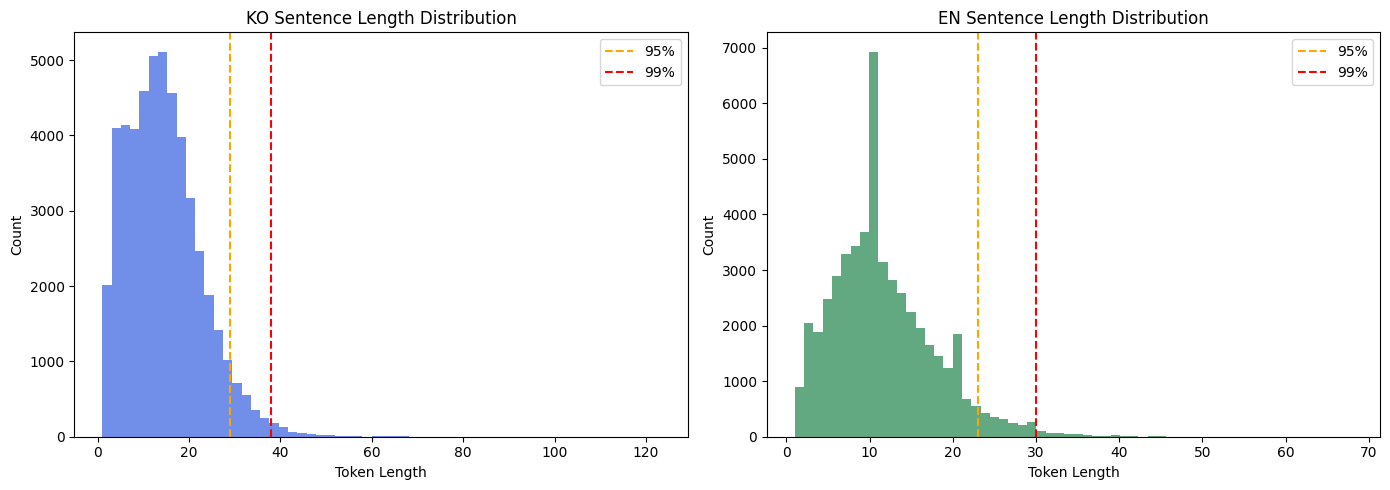

선택한 분위수 기준: 95%
KO cutoff: 29
EN cutoff: 23
최종 MAX_LENGTH: 31
KO 잘림 비율: 4.81%
EN 잘림 비율: 1.13%


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 길이 계산: 특수 토큰(SOS/EOS) 넣기 전 순수 토큰 길이
ko_lengths = np.array([len(tokenizer_ko(sent)) for sent in ko_sentences_train])
en_lengths = np.array([len(tokenizer_en(sent)) for sent in mt_sentences_train])

def print_length_stats(name, lengths):
    print(f"[{name}]")
    print(f"min    : {lengths.min()}")
    print(f"mean   : {lengths.mean():.2f}")
    print(f"median : {np.median(lengths):.2f}")
    print(f"95%    : {np.percentile(lengths, 95):.0f}")
    print(f"99%    : {np.percentile(lengths, 99):.0f}")
    print(f"max    : {lengths.max()}")
    print()

print_length_stats("KO", ko_lengths)
print_length_stats("EN", en_lengths)

# 분포 시각화
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(ko_lengths, bins=60, color="royalblue", alpha=0.75)
plt.axvline(np.percentile(ko_lengths, 95), color="orange", linestyle="--", label="95%")
plt.axvline(np.percentile(ko_lengths, 99), color="red", linestyle="--", label="99%")
plt.title("KO Sentence Length Distribution")
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(en_lengths, bins=60, color="seagreen", alpha=0.75)
plt.axvline(np.percentile(en_lengths, 95), color="orange", linestyle="--", label="95%")
plt.axvline(np.percentile(en_lengths, 99), color="red", linestyle="--", label="99%")
plt.title("EN Sentence Length Distribution")
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

# 95% 분위수 기준으로 MAX_LENGTH 설정
candidate_percentile = 95

ko_cutoff = int(np.ceil(np.percentile(ko_lengths, candidate_percentile)))
en_cutoff = int(np.ceil(np.percentile(en_lengths, candidate_percentile)))

# SOS, EOS 2개를 위한 +2
MAX_LENGTH = max(ko_cutoff, en_cutoff) + 2

print(f"선택한 분위수 기준: {candidate_percentile}%")
print(f"KO cutoff: {ko_cutoff}")
print(f"EN cutoff: {en_cutoff}")
print(f"최종 MAX_LENGTH: {MAX_LENGTH}")

# 이 길이를 썼을 때 실제로 잘리는 비율
ko_trunc_ratio = (ko_lengths > (MAX_LENGTH - 2)).mean()
en_trunc_ratio = (en_lengths > (MAX_LENGTH - 2)).mean()

print(f"KO 잘림 비율: {ko_trunc_ratio:.2%}")
print(f"EN 잘림 비율: {en_trunc_ratio:.2%}")


### vocab 분석

In [11]:
from collections import Counter
import numpy as np
import pandas as pd
from IPython.display import display

def build_counter(texts, tokenizer):
    counter = Counter()
    lengths = []

    for text in texts:
        tokens = tokenizer(text)
        counter.update(tokens)
        lengths.append(len(tokens))

    return counter, lengths

def summarize_vocab(counter, lengths, name, lang):
    total_tokens = sum(counter.values())
    vocab_size = len(counter)
    hapax_count = sum(1 for c in counter.values() if c == 1)
    low_freq_2 = sum(1 for c in counter.values() if c <= 2)
    low_freq_3 = sum(1 for c in counter.values() if c <= 3)

    return {
        "lang": lang,
        "tokenizer": name,
        "num_sentences": len(lengths),
        "avg_len": round(np.mean(lengths), 2),
        "median_len": round(np.median(lengths), 2),
        "p95_len": int(np.percentile(lengths, 95)),
        "max_len": int(np.max(lengths)),
        "total_tokens": total_tokens,
        "vocab_size": vocab_size,
        "hapax_ratio": round(hapax_count / vocab_size, 4) if vocab_size else 0.0,
        "low_freq<=2_ratio": round(low_freq_2 / vocab_size, 4) if vocab_size else 0.0,
        "low_freq<=3_ratio": round(low_freq_3 / vocab_size, 4) if vocab_size else 0.0,
    }

def compute_oov_ratio(train_texts, valid_texts, tokenizer):
    train_vocab = set()
    for text in train_texts:
        train_vocab.update(tokenizer(text))

    total_valid_tokens = 0
    oov_tokens = 0

    for text in valid_texts:
        tokens = tokenizer(text)
        total_valid_tokens += len(tokens)
        oov_tokens += sum(1 for tok in tokens if tok not in train_vocab)

    return round(oov_tokens / total_valid_tokens, 4) if total_valid_tokens else 0.0

ko_train_texts = train_raw_df["ko_raw"].tolist()
ko_valid_texts = valid_raw_df["ko_raw"].tolist()
en_train_texts = train_raw_df["en_raw"].tolist()
en_valid_texts = valid_raw_df["en_raw"].tolist()

ko_morph_counter, ko_morph_lengths = build_counter(ko_train_texts, tokenizer_ko_morph)
ko_subword_counter, ko_subword_lengths = build_counter(ko_train_texts, tokenizer_ko_subword)
en_word_counter, en_word_lengths = build_counter(en_train_texts, tokenizer_en_word)
en_subword_counter, en_subword_lengths = build_counter(en_train_texts, tokenizer_en_subword)

vocab_summary_df = pd.DataFrame([
    summarize_vocab(ko_morph_counter, ko_morph_lengths, "Kiwi_morph", "KO"),
    summarize_vocab(ko_subword_counter, ko_subword_lengths, "SentencePiece", "KO"),
    summarize_vocab(en_word_counter, en_word_lengths, "word_tokenize", "EN"),
    summarize_vocab(en_subword_counter, en_subword_lengths, "SentencePiece", "EN"),
])

vocab_summary_df["valid_oov_ratio"] = [
    compute_oov_ratio(ko_train_texts, ko_valid_texts, tokenizer_ko_morph),
    compute_oov_ratio(ko_train_texts, ko_valid_texts, tokenizer_ko_subword),
    compute_oov_ratio(en_train_texts, en_valid_texts, tokenizer_en_word),
    compute_oov_ratio(en_train_texts, en_valid_texts, tokenizer_en_subword),
]

display(vocab_summary_df)



,lang,tokenizer,num_sentences,avg_len,median_len,p95_len,max_len,total_tokens,vocab_size,hapax_ratio,low_freq<=2_ratio,low_freq<=3_ratio,valid_oov_ratio
0,KO,Kiwi_morph,50000,14.74,14.0,29,123,736990,18432,0.4170,0.5553,0.6297,0.0107
1,KO,SentencePiece,50000,11.72,10.0,24,96,585892,8266,0.0266,0.0422,0.0552,0.0003
2,EN,word_tokenize,50000,11.68,11.0,23,68,583983,21699,0.4516,0.5960,0.6687,0.0179
3,EN,SentencePiece,50000,13.09,12.0,26,89,654744,7775,0.0206,0.0401,0.0575,0.0001


In [12]:
def compute_oov_stats(train_counter, valid_texts, tokenizer, name):
    train_vocab = set(train_counter.keys())

    total_valid_tokens = 0
    oov_tokens = 0
    oov_token_set = set()

    for text in valid_texts:
        tokens = tokenizer(text)
        total_valid_tokens += len(tokens)

        for tok in tokens:
            if tok not in train_vocab:
                oov_tokens += 1
                oov_token_set.add(tok)

    oov_ratio = oov_tokens / total_valid_tokens if total_valid_tokens else 0.0

    return {
        "name": name,
        "valid_total_tokens": total_valid_tokens,
        "oov_tokens": oov_tokens,
        "oov_ratio": round(oov_ratio, 4),
        "unique_oov_tokens": len(oov_token_set),
        "sample_oov_tokens": list(sorted(oov_token_set))[:30],
    }

ko_valid_texts = valid_raw_df["ko_raw"].tolist()
en_valid_texts = valid_raw_df["en_raw"].tolist()

oov_results = [
    compute_oov_stats(ko_morph_counter, ko_valid_texts, tokenizer_ko_morph, "KO_Kiwi_morph"),
    compute_oov_stats(ko_subword_counter, ko_valid_texts, tokenizer_ko_subword, "KO_SentencePiece"),
    compute_oov_stats(en_word_counter, en_valid_texts, tokenizer_en_word, "EN_word_tokenize"),
    compute_oov_stats(en_subword_counter, en_valid_texts, tokenizer_en_subword, "EN_SentencePiece"),
]

oov_summary_df = pd.DataFrame([
    {k: v for k, v in row.items() if k != "sample_oov_tokens"} for row in oov_results
])

display(oov_summary_df)

for row in oov_results:
    print(f"\n[{row['name']}] sample OOV tokens")
    print(row["sample_oov_tokens"])


,name,valid_total_tokens,oov_tokens,oov_ratio,unique_oov_tokens
0,KO_Kiwi_morph,14824,158,0.0107,150
1,KO_SentencePiece,11934,4,0.0003,4
2,EN_word_tokenize,11862,212,0.0179,206
3,EN_SentencePiece,13357,2,0.0001,2



[KO_Kiwi_morph] sample OOV tokens
['09', '14.81', '2,000,000', '2346', '660', 'DMA', 'GMO', 'GPH', 'Jack', 'Marketing', 'PND', 'pf', 'wleightons@epmedin.co.uk', 'ᆻ', '가뭄', '각기', '건희', '경상남도', '고참', '과감히', '관광공사', '그다지', '글렌체크', '글루', '김하나', '김희', '깅엄체크', '까뒤집', '꺼림칙', '내가']

[KO_SentencePiece] sample OOV tokens
['멱', '밈', '뼛', '켭']

[EN_word_tokenize] sample OOV tokens
["'out", "'positioning", '0.5', '00', '100GPH', '120GB', '14.81', '150GPH', '190ml', '2,000,000', '200GPH', '2346', '33kg', '350-dollar', '350GPH', '400G', '400g', '480GB', '50-100', '63', '660', '75GPH', '8-inch', '800G', 'Abalone', 'Accredited', 'Ancient', 'Beta-glucan', 'Board', 'Comments']

[EN_SentencePiece] sample OOV tokens
['ilar', 'rough']


### split 점검

In [13]:
split_summary_df = pd.DataFrame({
    "split": ["train", "valid"],
    "num_pairs": [len(train_raw_df), len(valid_raw_df)],
})

total_pairs = split_summary_df["num_pairs"].sum()
split_summary_df["ratio"] = (split_summary_df["num_pairs"] / total_pairs).round(4)
split_summary_df["percent"] = (split_summary_df["ratio"] * 100).round(2)

display(split_summary_df)

print(f"Train : Valid = {len(train_raw_df)} : {len(valid_raw_df)}")
print(f"대략 비율 = {len(train_raw_df) / len(valid_raw_df):.2f} : 1")


,split,num_pairs,ratio,percent
0,train,50000,0.9804,98.04
1,valid,1000,0.0196,1.96


Train : Valid = 50000 : 1000
대략 비율 = 50.00 : 1


In [14]:
def get_length_stats(texts, tokenizer, split_name, lang):
    lengths = [len(tokenizer(text)) for text in texts]
    return {
        "split": split_name,
        "lang": lang,
        "avg_len": round(np.mean(lengths), 2),
        "median_len": round(np.median(lengths), 2),
        "p95_len": int(np.percentile(lengths, 95)),
        "max_len": int(np.max(lengths)),
    }

split_length_df = pd.DataFrame([
    get_length_stats(train_raw_df["ko_raw"].tolist(), tokenizer_ko_morph, "train", "KO"),
    get_length_stats(valid_raw_df["ko_raw"].tolist(), tokenizer_ko_morph, "valid", "KO"),
    get_length_stats(train_raw_df["en_raw"].tolist(), tokenizer_en_word, "train", "EN"),
    get_length_stats(valid_raw_df["en_raw"].tolist(), tokenizer_en_word, "valid", "EN"),
])

display(split_length_df)


,split,lang,avg_len,median_len,p95_len,max_len
0,train,KO,14.74,14.0,29,123
1,valid,KO,14.82,14.0,29,67
2,train,EN,11.68,11.0,23,68
3,valid,EN,11.86,11.0,24,50


## 전처리

### 중복 제거

In [15]:
import re
import unicodedata

def normalize_pair_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\u200b", " ").replace("\xa0", " ").replace("\ufeff", " ")
    text = text.replace("\r", " ").replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_pre_df = train_raw_df.copy()
valid_pre_df = valid_raw_df.copy()

for df in [train_pre_df, valid_pre_df]:
    df["ko_norm"] = df["ko_raw"].apply(normalize_pair_text)
    df["en_norm"] = df["en_raw"].apply(normalize_pair_text)

train_duplicate_mask = train_pre_df.duplicated(subset=["ko_norm", "en_norm"], keep="first")
valid_duplicate_mask = valid_pre_df.duplicated(subset=["ko_norm", "en_norm"], keep="first")

train_removed_count = int(train_duplicate_mask.sum())
valid_removed_count = int(valid_duplicate_mask.sum())

train_pre_df = train_pre_df.loc[~train_duplicate_mask].reset_index(drop=True)
valid_pre_df = valid_pre_df.loc[~valid_duplicate_mask].reset_index(drop=True)

dedup_summary_df = pd.DataFrame({
    "split": ["train", "valid"],
    "before": [len(train_raw_df), len(valid_raw_df)],
    "removed_exact_duplicates": [train_removed_count, valid_removed_count],
    "after": [len(train_pre_df), len(valid_pre_df)],
})

display(dedup_summary_df)


,split,before,removed_exact_duplicates,after
0,train,50000,2320,47680
1,valid,1000,4,996


### 제거 결과 확인

In [16]:
train_removed_examples = train_raw_df.loc[
    train_raw_df.assign(
        ko_norm=train_raw_df["ko_raw"].apply(normalize_pair_text),
        en_norm=train_raw_df["en_raw"].apply(normalize_pair_text)
    ).duplicated(subset=["ko_norm", "en_norm"], keep="first"),
    ["ko_raw", "en_raw"]
].head(10)

print("[train] 제거된 exact duplicate 예시")
display(train_removed_examples)

ko_sentences_train_clean = train_pre_df["ko_norm"].tolist()
en_sentences_train_clean = train_pre_df["en_norm"].tolist()
ko_sentences_valid_clean = valid_pre_df["ko_norm"].tolist()
en_sentences_valid_clean = valid_pre_df["en_norm"].tolist()

print(f"정제 후 train pair 수: {len(ko_sentences_train_clean)}")
print(f"정제 후 valid pair 수: {len(ko_sentences_valid_clean)}")


[train] 제거된 exact duplicate 예시


,ko_raw,en_raw
325,>네.,>Yes.
364,>네.,>Yes.
371,>네.,>Yes.
498,>네.,>Yes.
586,>그러니까.,I know.
763,>그렇죠.,>That's right.
809,> 오케이.,> Okay.
870,>그러니까.,I know.
995,>그래요?,Is that so?
1051,미리 감사드립니다.,Thank you in advance.


정제 후 train pair 수: 47680
정제 후 valid pair 수: 996


### 중복 제거 후 split 비율

In [17]:
# 중복 제거 후 split 비율 재확인
split_after_dedup_df = pd.DataFrame({
    "split": ["train", "valid"],
    "num_pairs": [len(train_pre_df), len(valid_pre_df)],
})

total_pairs_after_dedup = split_after_dedup_df["num_pairs"].sum()
split_after_dedup_df["ratio"] = (split_after_dedup_df["num_pairs"] / total_pairs_after_dedup).round(4)
split_after_dedup_df["percent"] = (split_after_dedup_df["ratio"] * 100).round(2)

display(split_after_dedup_df)

print(f"중복 제거 후 Train : Valid = {len(train_pre_df)} : {len(valid_pre_df)}")
print(f"대략 비율 = {len(train_pre_df) / len(valid_pre_df):.2f} : 1")


,split,num_pairs,ratio,percent
0,train,47680,0.9795,97.95
1,valid,996,0.0205,2.05


중복 제거 후 Train : Valid = 47680 : 996
대략 비율 = 47.87 : 1


In [18]:
import numpy as np
import pandas as pd

def get_length_stats(texts, tokenizer, split_name, lang):
    lengths = [len(tokenizer(text)) for text in texts]
    return {
        "split": split_name,
        "lang": lang,
        "avg_len": round(np.mean(lengths), 2),
        "median_len": round(np.median(lengths), 2),
        "p95_len": int(np.percentile(lengths, 95)),
        "max_len": int(np.max(lengths)),
    }

split_length_after_dedup_df = pd.DataFrame([
    get_length_stats(train_pre_df["ko_norm"].tolist(), tokenizer_ko_morph, "train", "KO"),
    get_length_stats(valid_pre_df["ko_norm"].tolist(), tokenizer_ko_morph, "valid", "KO"),
    get_length_stats(train_pre_df["en_norm"].tolist(), tokenizer_en_word, "train", "EN"),
    get_length_stats(valid_pre_df["en_norm"].tolist(), tokenizer_en_word, "valid", "EN"),
])

display(split_length_after_dedup_df)


,split,lang,avg_len,median_len,p95_len,max_len
0,train,KO,15.22,14.0,30,123
1,valid,KO,14.87,14.0,29,67
2,train,EN,12.05,11.0,23,68
3,valid,EN,11.90,11.0,24,50


### 정규화

In [19]:
import re
import pandas as pd

def has_leading_gt_marker(text):
    return bool(re.match(r"^\s*>+\s*", str(text)))

def normalize_translation_text(text):
    text = normalize_pair_text(text)

    # 대화 데이터에서 의미가 약한 앞쪽 마커(>) 제거
    text = re.sub(r"^\s*>+\s*", "", text)

    # 문장부호 앞쪽 불필요 공백 정리
    text = re.sub(r"\s+([?.!,;:])", r"\1", text)

    # 괄호/따옴표 주변 공백 정리
    text = re.sub(r'([\(\[\{\"\'])\s+', r"\1", text)
    text = re.sub(r'\s+([\)\]\}\"\'])', r"\1", text)

    # 마지막 공백 재정리
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_final_df = train_pre_df.copy()
valid_final_df = valid_pre_df.copy()

for df in [train_final_df, valid_final_df]:
    df["ko_had_gt_marker"] = df["ko_norm"].apply(has_leading_gt_marker)
    df["en_had_gt_marker"] = df["en_norm"].apply(has_leading_gt_marker)
    df["ko_final"] = df["ko_norm"].apply(normalize_translation_text)
    df["en_final"] = df["en_norm"].apply(normalize_translation_text)
    df["ko_changed"] = df["ko_norm"] != df["ko_final"]
    df["en_changed"] = df["en_norm"] != df["en_final"]

train_empty_after_norm = (train_final_df["ko_final"] == "") | (train_final_df["en_final"] == "")
valid_empty_after_norm = (valid_final_df["ko_final"] == "") | (valid_final_df["en_final"] == "")

norm_summary_df = pd.DataFrame({
    "split": ["train", "valid"],
    "ko_leading_gt_count": [int(train_final_df["ko_had_gt_marker"].sum()), int(valid_final_df["ko_had_gt_marker"].sum())],
    "en_leading_gt_count": [int(train_final_df["en_had_gt_marker"].sum()), int(valid_final_df["en_had_gt_marker"].sum())],
    "ko_changed_count": [int(train_final_df["ko_changed"].sum()), int(valid_final_df["ko_changed"].sum())],
    "en_changed_count": [int(train_final_df["en_changed"].sum()), int(valid_final_df["en_changed"].sum())],
    "empty_after_normalization": [int(train_empty_after_norm.sum()), int(valid_empty_after_norm.sum())],
})

display(norm_summary_df)

train_final_df = train_final_df.loc[~train_empty_after_norm].reset_index(drop=True)
valid_final_df = valid_final_df.loc[~valid_empty_after_norm].reset_index(drop=True)

changed_examples = train_final_df.loc[
    train_final_df["ko_changed"] | train_final_df["en_changed"],
    ["ko_norm", "ko_final", "en_norm", "en_final"]
].head(10)

print("[train] 정규화로 변경된 예시")
display(changed_examples)

ko_sentences_train_final = train_final_df["ko_final"].tolist()
en_sentences_train_final = train_final_df["en_final"].tolist()
ko_sentences_valid_final = valid_final_df["ko_final"].tolist()
en_sentences_valid_final = valid_final_df["en_final"].tolist()

print(f"정규화 후 train pair 수: {len(ko_sentences_train_final)}")
print(f"정규화 후 valid pair 수: {len(ko_sentences_valid_final)}")


,split,ko_leading_gt_count,en_leading_gt_count,ko_changed_count,en_changed_count,empty_after_normalization
0,train,10134,7604,10317,7921,0
1,valid,223,165,226,173,0


[train] 정규화로 변경된 예시


,ko_norm,ko_final,en_norm,en_final
2,>속옷을?,속옷을?,Underwear?,Underwear?
5,>회식하거든.,회식하거든.,>We're having a get-together.,We're having a get-together.
10,>제가 이걸 보여드리겠습니다.,제가 이걸 보여드리겠습니다.,Let me show you this.,Let me show you this.
18,">지금도, 지금도 보면 다들 고개를 끄덕끄덕했잖아.","지금도, 지금도 보면 다들 고개를 끄덕끄덕했잖아.","> Even now, if you look at it now, everyone no...","Even now, if you look at it now, everyone nodded."
19,">하다가 못 하겠으면 얘기해요, 포기.","하다가 못 하겠으면 얘기해요, 포기.","Let me know if you can't, give up.","Let me know if you can't, give up."
24,">형, 뭐야?","형, 뭐야?","> Hyung, what is this way?","Hyung, what is this way?"
26,>와우영미.,와우영미.,"> Wow, Woo Youngmi.","Wow, Woo Youngmi."
30,">여러분, 이제 두 번째 미션인데요.","여러분, 이제 두 번째 미션인데요.","Everyone, this is the second mission.","Everyone, this is the second mission."
32,>그래요.,그래요.,>Yes.,Yes.
38,">아, OK, OK.","아, OK, OK.","Oh, okay, okay.","Oh, okay, okay."


정규화 후 train pair 수: 47680
정규화 후 valid pair 수: 996


### 최종 tokenizer 선택

In [20]:
import os
import sentencepiece as spm

KO_FINAL_VOCAB_SIZE = 8000
EN_FINAL_VOCAB_SIZE = 8000

def write_spm_input(path, texts):
    with open(path, "w", encoding="utf-8") as f:
        for sent in texts:
            sent = str(sent).strip()
            if sent:
                f.write(sent + "\n")

def remove_if_exists(path):
    if os.path.exists(path):
        os.remove(path)

ko_spm_input = "/content/ko_train_final_for_spm.txt"
en_spm_input = "/content/en_train_final_for_spm.txt"
ko_model_prefix = "/content/ko_final_spm_bpe_8000"
en_model_prefix = "/content/en_final_spm_bpe_8000"

write_spm_input(ko_spm_input, ko_sentences_train_final)
write_spm_input(en_spm_input, en_sentences_train_final)

for suffix in [".model", ".vocab"]:
    remove_if_exists(ko_model_prefix + suffix)
    remove_if_exists(en_model_prefix + suffix)

spm.SentencePieceTrainer.train(
    input=ko_spm_input,
    model_prefix=ko_model_prefix,
    vocab_size=KO_FINAL_VOCAB_SIZE,
    model_type="bpe",
    character_coverage=0.9995,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="[PAD]",
    unk_piece="[UNK]",
    bos_piece="[SOS]",
    eos_piece="[EOS]"
)

spm.SentencePieceTrainer.train(
    input=en_spm_input,
    model_prefix=en_model_prefix,
    vocab_size=EN_FINAL_VOCAB_SIZE,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="[PAD]",
    unk_piece="[UNK]",
    bos_piece="[SOS]",
    eos_piece="[EOS]"
)

sp_ko_final = spm.SentencePieceProcessor()
sp_ko_final.load(ko_model_prefix + ".model")

sp_en_final = spm.SentencePieceProcessor()
sp_en_final.load(en_model_prefix + ".model")

def tokenizer_ko_final(text):
    return sp_ko_final.encode(str(text), out_type=str)

def tokenizer_en_final(text):
    return sp_en_final.encode(str(text), out_type=str)

print(f"최종 한국어 tokenizer: SentencePiece BPE {KO_FINAL_VOCAB_SIZE}")
print(f"최종 영어 tokenizer: SentencePiece BPE {EN_FINAL_VOCAB_SIZE}")


최종 한국어 tokenizer: SentencePiece BPE 8000
최종 영어 tokenizer: SentencePiece BPE 8000


### 최종 길이 재설정

,split,side,avg_len,median_len,p95_len,p97_len,p99_len,max_len
0,train,SRC_KO,11.83,11.0,24,27,34,96
1,valid,SRC_KO,11.68,11.0,25,29,34,55
2,train,TGT_EN,13.33,12.0,27,30,36,89
3,valid,TGT_EN,13.22,12.0,27,31,39,55


,percentile,SRC_cutoff_no_special,TGT_cutoff_no_special,SRC_trunc_ratio,TGT_trunc_ratio
0,95,24,27,0.0494,0.0438
1,97,27,30,0.0297,0.0258
2,99,34,36,0.0088,0.0085


최종 percentile 기준: 95%
SRC_MAX_LENGTH (KO): 26
TGT_MAX_LENGTH (EN): 29
기존 코드 호환용 MAX_LENGTH: 29
KO 잘림 비율: 4.94%
EN 잘림 비율: 4.38%


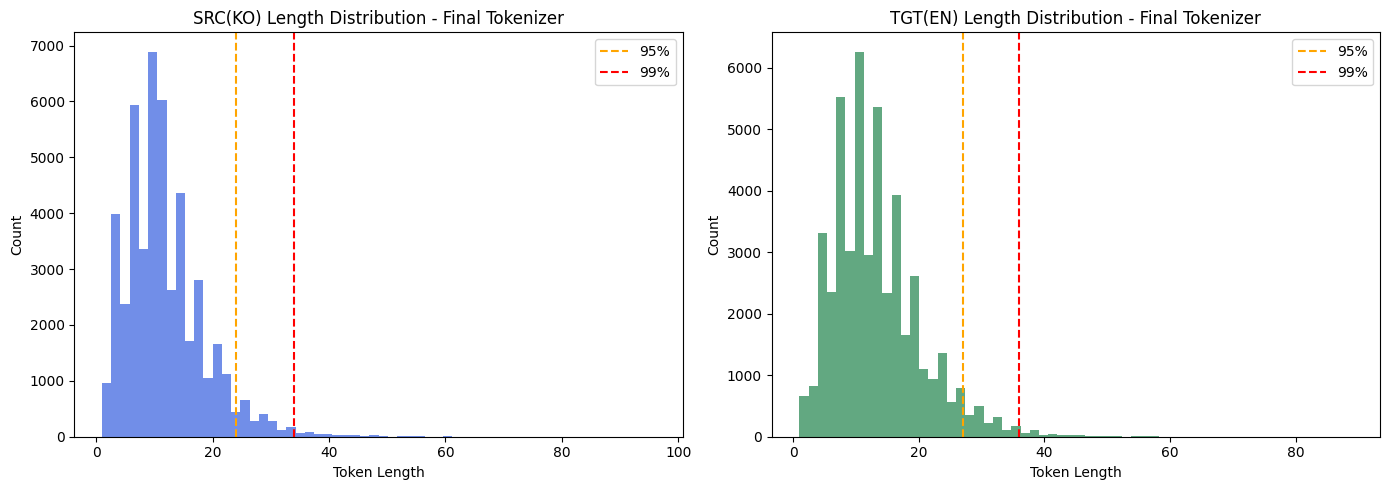

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

src_train_lengths = np.array([len(tokenizer_ko_final(text)) for text in ko_sentences_train_final])
tgt_train_lengths = np.array([len(tokenizer_en_final(text)) for text in en_sentences_train_final])
src_valid_lengths = np.array([len(tokenizer_ko_final(text)) for text in ko_sentences_valid_final])
tgt_valid_lengths = np.array([len(tokenizer_en_final(text)) for text in en_sentences_valid_final])

def summarize_lengths(lengths, split_name, side_name):
    return {
        "split": split_name,
        "side": side_name,
        "avg_len": round(np.mean(lengths), 2),
        "median_len": round(np.median(lengths), 2),
        "p95_len": int(np.percentile(lengths, 95)),
        "p97_len": int(np.percentile(lengths, 97)),
        "p99_len": int(np.percentile(lengths, 99)),
        "max_len": int(np.max(lengths)),
    }

final_length_summary_df = pd.DataFrame([
    summarize_lengths(src_train_lengths, "train", "SRC_KO"),
    summarize_lengths(src_valid_lengths, "valid", "SRC_KO"),
    summarize_lengths(tgt_train_lengths, "train", "TGT_EN"),
    summarize_lengths(tgt_valid_lengths, "valid", "TGT_EN"),
])

display(final_length_summary_df)

percentile_compare_df = pd.DataFrame([
    {
        "percentile": p,
        "SRC_cutoff_no_special": int(np.ceil(np.percentile(src_train_lengths, p))),
        "TGT_cutoff_no_special": int(np.ceil(np.percentile(tgt_train_lengths, p))),
        "SRC_trunc_ratio": round(float((src_train_lengths > np.ceil(np.percentile(src_train_lengths, p))).mean()), 4),
        "TGT_trunc_ratio": round(float((tgt_train_lengths > np.ceil(np.percentile(tgt_train_lengths, p))).mean()), 4),
    }
    for p in [95, 97, 99]
])

display(percentile_compare_df)

# 최종 선택: 99% 기준 + SOS/EOS 2개
LENGTH_PERCENTILE = 95
SRC_MAX_LENGTH = int(np.ceil(np.percentile(src_train_lengths, LENGTH_PERCENTILE))) + 2
TGT_MAX_LENGTH = int(np.ceil(np.percentile(tgt_train_lengths, LENGTH_PERCENTILE))) + 2
MAX_LENGTH = max(SRC_MAX_LENGTH, TGT_MAX_LENGTH)

src_trunc_ratio = (src_train_lengths > (SRC_MAX_LENGTH - 2)).mean()
tgt_trunc_ratio = (tgt_train_lengths > (TGT_MAX_LENGTH - 2)).mean()

print(f"최종 percentile 기준: {LENGTH_PERCENTILE}%")
print(f"SRC_MAX_LENGTH (KO): {SRC_MAX_LENGTH}")
print(f"TGT_MAX_LENGTH (EN): {TGT_MAX_LENGTH}")
print(f"기존 코드 호환용 MAX_LENGTH: {MAX_LENGTH}")
print(f"KO 잘림 비율: {src_trunc_ratio:.2%}")
print(f"EN 잘림 비율: {tgt_trunc_ratio:.2%}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(src_train_lengths, bins=60, color="royalblue", alpha=0.75)
plt.axvline(np.percentile(src_train_lengths, 95), color="orange", linestyle="--", label="95%")
plt.axvline(np.percentile(src_train_lengths, 99), color="red", linestyle="--", label="99%")
plt.title("SRC(KO) Length Distribution - Final Tokenizer")
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(tgt_train_lengths, bins=60, color="seagreen", alpha=0.75)
plt.axvline(np.percentile(tgt_train_lengths, 95), color="orange", linestyle="--", label="95%")
plt.axvline(np.percentile(tgt_train_lengths, 99), color="red", linestyle="--", label="99%")
plt.title("TGT(EN) Length Distribution - Final Tokenizer")
plt.xlabel("Token Length")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()


## 최종 학습 및 실험

### 데이터, Vocab, Model 정의


In [22]:
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SOS_token = 0
EOS_token = 1
PAD_token = 2
UNK_token = 3

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {
            "SOS": SOS_token,
            "EOS": EOS_token,
            "PAD": PAD_token,
            "<unk>": UNK_token,
        }
        self.index2word = {
            SOS_token: "SOS",
            EOS_token: "EOS",
            PAD_token: "PAD",
            UNK_token: "<unk>",
        }
        self.word2count = {"SOS": 0, "EOS": 0, "PAD": 0, "<unk>": 0}
        self.n_words = 4

    def addSentence(self, sentence, tokenizer):
        for word in tokenizer(sentence):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word2count[word] = 1
            self.n_words += 1
        else:
            self.word2count[word] += 1

class EncoderRNNExperiment(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1, bidirectional=False):
        super().__init__()
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(
            hidden_size,
            hidden_size,
            batch_first=True,
            bidirectional=bidirectional,
        )
        self.dropout = nn.Dropout(dropout_p)

        if bidirectional:
            self.output_proj = nn.Linear(hidden_size * 2, hidden_size)
            self.hidden_proj = nn.Linear(hidden_size * 2, hidden_size)
        else:
            self.output_proj = None
            self.hidden_proj = None

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)

        if self.bidirectional:
            output = self.output_proj(output)
            hidden = hidden.permute(1, 0, 2).reshape(input.size(0), -1)
            hidden = self.hidden_proj(hidden).unsqueeze(0)

        return output, hidden

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)
        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super().__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None, teacher_forcing_ratio=0.7):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            use_teacher_forcing = (
                target_tensor is not None and random.random() < teacher_forcing_ratio
            )

            if use_teacher_forcing:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)
        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input))
        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)
        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)
        return output, hidden, attn_weights

pairs_train_final = list(zip(ko_sentences_train_final, en_sentences_train_final))
pairs_valid_final = list(zip(ko_sentences_valid_final, en_sentences_valid_final))

def prepareData_final(lang1, lang2, sentence_pairs, tokenizer1, tokenizer2):
    input_lang = Lang(lang1)
    output_lang = Lang(lang2)

    for src_sentence, tgt_sentence in sentence_pairs:
        input_lang.addSentence(src_sentence, tokenizer1)
        output_lang.addSentence(tgt_sentence, tokenizer2)

    return input_lang, output_lang

input_lang_final, output_lang_final = prepareData_final(
    "ko", "en", pairs_train_final, tokenizer_ko_final, tokenizer_en_final
)

print(f"Final train pairs: {len(pairs_train_final)}")
print(f"Final valid pairs: {len(pairs_valid_final)}")
print(f"Final input vocab size: {input_lang_final.n_words}")
print(f"Final output vocab size: {output_lang_final.n_words}")


Final train pairs: 47680
Final valid pairs: 996
Final input vocab size: 8227
Final output vocab size: 7772


### 데이터 가져오기


In [23]:
from torch.utils.data import DataLoader, TensorDataset, RandomSampler

def tensorFromSentence_final(lang, sentence, tokenizer, max_length):
    indexes = [SOS_token]
    indexes += [lang.word2index.get(word, UNK_token) for word in tokenizer(sentence)[:max_length - 2]]
    indexes.append(EOS_token)

    while len(indexes) < max_length:
        indexes.append(PAD_token)

    return torch.tensor(indexes[:max_length], dtype=torch.long, device=device)

def build_tensor_dataset(pairs, input_lang, output_lang, src_tokenizer, tgt_tokenizer, max_length):
    input_tensors = [
        tensorFromSentence_final(input_lang, src, src_tokenizer, max_length)
        for src, _ in pairs
    ]
    target_tensors = [
        tensorFromSentence_final(output_lang, tgt, tgt_tokenizer, max_length)
        for _, tgt in pairs
    ]

    input_tensors = torch.stack(input_tensors, dim=0)
    target_tensors = torch.stack(target_tensors, dim=0)

    dataset = TensorDataset(input_tensors, target_tensors)
    return dataset, input_tensors.shape, target_tensors.shape

def get_dataloaders_final(batch_size):
    train_dataset, train_input_shape, train_target_shape = build_tensor_dataset(
        pairs_train_final, input_lang_final, output_lang_final,
        tokenizer_ko_final, tokenizer_en_final, MAX_LENGTH
    )

    valid_dataset, valid_input_shape, valid_target_shape = build_tensor_dataset(
        pairs_valid_final, input_lang_final, output_lang_final,
        tokenizer_ko_final, tokenizer_en_final, MAX_LENGTH
    )

    train_sampler = RandomSampler(train_dataset)

    train_dataloader = DataLoader(train_dataset, sampler=train_sampler, batch_size=batch_size)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

    print(f"train input shape:  {train_input_shape}")
    print(f"train target shape: {train_target_shape}")
    print(f"valid input shape:  {valid_input_shape}")
    print(f"valid target shape: {valid_target_shape}")

    return train_dataloader, valid_dataloader


### 모델 학습 & 검증 정의


In [24]:
import torch.optim as optim
import pandas as pd

def train_epoch_final(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, teacher_forcing_ratio=0.7):
    encoder.train()
    decoder.train()

    total_loss = 0

    for input_tensor, target_tensor in dataloader:
        input_tensor = input_tensor.long().to(device)
        target_tensor = target_tensor.long().to(device)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(
            encoder_outputs,
            encoder_hidden,
            target_tensor,
            teacher_forcing_ratio=teacher_forcing_ratio,
        )

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )

        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def evaluate_loss_final(dataloader, encoder, decoder, criterion):
    encoder.eval()
    decoder.eval()

    total_loss = 0

    with torch.no_grad():
        for input_tensor, target_tensor in dataloader:
            input_tensor = input_tensor.long().to(device)
            target_tensor = target_tensor.long().to(device)

            encoder_outputs, encoder_hidden = encoder(input_tensor)
            decoder_outputs, _, _ = decoder(
                encoder_outputs,
                encoder_hidden,
                target_tensor,
                teacher_forcing_ratio=1.0,
            )

            loss = criterion(
                decoder_outputs.view(-1, decoder_outputs.size(-1)),
                target_tensor.view(-1)
            )

            total_loss += loss.item()

    return total_loss / len(dataloader)

def train_seq2seq_final(
    train_dataloader,
    valid_dataloader,
    encoder,
    decoder,
    n_epochs,
    learning_rate=0.001,
    patience=5,
    print_every=1,
    teacher_forcing_ratio=0.7,
):
    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss(ignore_index=PAD_token)

    history = []
    best_valid_loss = float("inf")
    best_epoch = 0
    early_stop_counter = 0

    best_encoder_state = None
    best_decoder_state = None

    for epoch in range(1, n_epochs + 1):
        train_loss = train_epoch_final(
            train_dataloader,
            encoder,
            decoder,
            encoder_optimizer,
            decoder_optimizer,
            criterion,
            teacher_forcing_ratio=teacher_forcing_ratio,
        )

        valid_loss = evaluate_loss_final(valid_dataloader, encoder, decoder, criterion)
        improved = valid_loss < best_valid_loss

        if improved:
            best_valid_loss = valid_loss
            best_epoch = epoch
            early_stop_counter = 0
            best_encoder_state = copy.deepcopy(encoder.state_dict())
            best_decoder_state = copy.deepcopy(decoder.state_dict())
        else:
            early_stop_counter += 1

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "best_valid_loss_so_far": best_valid_loss,
            "improved": improved,
            "early_stop_counter": early_stop_counter,
            "teacher_forcing_ratio": teacher_forcing_ratio,
        })

        if epoch % print_every == 0:
            print(
                f"Epoch {epoch}/{n_epochs} | "
                f"train_loss={train_loss:.4f} | "
                f"valid_loss={valid_loss:.4f} | "
                f"teacher_forcing_ratio={teacher_forcing_ratio:.2f} | "
                f"best_epoch={best_epoch} | "
                f"patience={early_stop_counter}/{patience}"
            )

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}")
            break

    if best_encoder_state is not None:
        encoder.load_state_dict(best_encoder_state)
        decoder.load_state_dict(best_decoder_state)

    history_df = pd.DataFrame(history)

    print(f"\nBest epoch: {best_epoch}")
    print(f"Best valid loss: {best_valid_loss:.4f}")
    print("Best model weights restored.")

    return history_df, best_epoch, best_valid_loss


### 추론 및 평가 함수


In [25]:
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def decode_sentencepiece_output(tokens, sp_processor):
    special_tokens = {"SOS", "EOS", "PAD"}
    clean_tokens = [tok for tok in tokens if tok not in special_tokens and tok != "<unk>"]
    decoded_text = sp_processor.decode(clean_tokens).strip()

    if "<unk>" in tokens:
        decoded_text = (decoded_text + " <unk>").strip()

    return decoded_text

def evaluate_final(encoder, decoder, sentence, input_lang, output_lang):
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        input_tensor = tensorFromSentence_final(input_lang, sentence, tokenizer_ko_final, MAX_LENGTH).unsqueeze(0)
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_tokens = []
        for idx in decoded_ids:
            token = output_lang.index2word[idx.item()]
            if idx.item() == EOS_token:
                break
            decoded_tokens.append(token)

        decoded_text = decode_sentencepiece_output(decoded_tokens, sp_en_final)

    return decoded_tokens, decoded_text, decoder_attn

def evaluateRandomly_final(encoder, decoder, evaluation_pairs, n=10):
    for _ in range(n):
        src_sentence, tgt_sentence = random.choice(evaluation_pairs)
        output_tokens, output_text, _ = evaluate_final(
            encoder, decoder, src_sentence, input_lang_final, output_lang_final
        )
        print(">", src_sentence)
        print("=", tgt_sentence)
        print("<", output_text)
        print("subword:", output_tokens)
        print("")

def calculate_bleu_score_final(encoder, decoder, evaluation_pairs, input_lang, output_lang):
    encoder.eval()
    decoder.eval()

    total_bleu = 0
    smoothie = SmoothingFunction().method1

    print(f"Calculating BLEU for {len(evaluation_pairs)} pairs...")

    with torch.no_grad():
        for src_sentence, tgt_sentence in evaluation_pairs:
            _, predicted_text, _ = evaluate_final(encoder, decoder, src_sentence, input_lang, output_lang)
            reference = [word_tokenize(tgt_sentence)]
            candidate = word_tokenize(predicted_text) if predicted_text else []
            score = sentence_bleu(reference, candidate, smoothing_function=smoothie)
            total_bleu += score

    avg_bleu = total_bleu / len(evaluation_pairs)
    print(f"Average BLEU Score: {avg_bleu:.4f}")
    return avg_bleu


### BERTScore


In [26]:
!pip install -q bert-score

from bert_score import score as bertscore_score

def calculate_bertscore_final(encoder, decoder, evaluation_pairs, input_lang, output_lang, lang="en"):
    encoder.eval()
    decoder.eval()

    references = []
    candidates = []

    print(f"Calculating BERTScore for {len(evaluation_pairs)} pairs...")

    with torch.no_grad():
        for src_sentence, tgt_sentence in evaluation_pairs:
            _, predicted_text, _ = evaluate_final(encoder, decoder, src_sentence, input_lang, output_lang)
            references.append(tgt_sentence)
            candidates.append(predicted_text if predicted_text else "")

    P, R, F1 = bertscore_score(candidates, references, lang=lang, verbose=True)

    bertscore_df = pd.DataFrame({
        "reference": references,
        "candidate": candidates,
        "bert_precision": P.cpu().numpy(),
        "bert_recall": R.cpu().numpy(),
        "bert_f1": F1.cpu().numpy(),
    })

    bertscore_summary = {
        "bert_precision_mean": round(P.mean().item(), 4),
        "bert_recall_mean": round(R.mean().item(), 4),
        "bert_f1_mean": round(F1.mean().item(), 4),
    }

    print(f"Average BERTScore Precision: {bertscore_summary['bert_precision_mean']:.4f}")
    print(f"Average BERTScore Recall:    {bertscore_summary['bert_recall_mean']:.4f}")
    print(f"Average BERTScore F1:        {bertscore_summary['bert_f1_mean']:.4f}")

    return bertscore_df, bertscore_summary


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.9 MB/s eta 0:00:00


### 단,양방향 & Batch Size 실험


In [28]:
import time
import gc

EXPERIMENT_ENCODER_DIRECTIONS = ["unidirectional", "bidirectional"]
EXPERIMENT_BATCH_SIZES = [32, 64]

hidden_size = 128
n_epochs = 30
learning_rate = 0.001
patience = 5
teacher_forcing_ratio = 0.7

experiment_results = []
experiment_histories = {}

best_overall = {
    "best_valid_loss": float("inf"),
    "encoder": None,
    "decoder": None,
    "config": None,
    "history": None,
}

for encoder_direction in EXPERIMENT_ENCODER_DIRECTIONS:
    for batch_size in EXPERIMENT_BATCH_SIZES:
        print("=" * 100)
        print(f"[direction={encoder_direction}, batch_size={batch_size}] start")

        start_time = time.time()
        run_key = f"{encoder_direction}_bs{batch_size}"

        try:
            train_dataloader_exp, valid_dataloader_exp = get_dataloaders_final(batch_size=batch_size)

            encoder_exp = EncoderRNNExperiment(
                input_lang_final.n_words,
                hidden_size,
                bidirectional=(encoder_direction == "bidirectional"),
            ).to(device)
            decoder_exp = AttnDecoderRNN(hidden_size, output_lang_final.n_words).to(device)

            history_df, best_epoch, best_valid_loss = train_seq2seq_final(
                train_dataloader=train_dataloader_exp,
                valid_dataloader=valid_dataloader_exp,
                encoder=encoder_exp,
                decoder=decoder_exp,
                n_epochs=n_epochs,
                learning_rate=learning_rate,
                patience=patience,
                print_every=1,
                teacher_forcing_ratio=teacher_forcing_ratio,
            )

            bleu_score = calculate_bleu_score_final(
                encoder_exp,
                decoder_exp,
                pairs_valid_final,
                input_lang_final,
                output_lang_final,
            )

            elapsed_time = round(time.time() - start_time, 2)
            experiment_histories[run_key] = history_df.copy()

            result_row = {
                "run_key": run_key,
                "encoder_direction": encoder_direction,
                "batch_size": batch_size,
                "best_epoch": int(best_epoch),
                "best_valid_loss": round(float(best_valid_loss), 4),
                "final_train_loss": round(float(history_df["train_loss"].iloc[-1]), 4),
                "final_valid_loss": round(float(history_df["valid_loss"].iloc[-1]), 4),
                "bleu_score": round(float(bleu_score), 4),
                "num_epochs_ran": int(len(history_df)),
                "teacher_forcing_ratio": teacher_forcing_ratio,
                "elapsed_sec": elapsed_time,
                "status": "success",
            }
            experiment_results.append(result_row)

            if best_valid_loss < best_overall["best_valid_loss"]:
                best_overall["best_valid_loss"] = float(best_valid_loss)
                best_overall["encoder"] = copy.deepcopy(encoder_exp).cpu()
                best_overall["decoder"] = copy.deepcopy(decoder_exp).cpu()
                best_overall["config"] = result_row.copy()
                best_overall["history"] = history_df.copy()

            print(
                f"[direction={encoder_direction}, batch_size={batch_size}] done | "
                f"best_epoch={best_epoch}, best_valid_loss={best_valid_loss:.4f}, bleu={bleu_score:.4f}"
            )

        except RuntimeError as e:
            elapsed_time = round(time.time() - start_time, 2)
            error_msg = str(e)
            experiment_results.append({
                "run_key": run_key,
                "encoder_direction": encoder_direction,
                "batch_size": batch_size,
                "best_epoch": None,
                "best_valid_loss": None,
                "final_train_loss": None,
                "final_valid_loss": None,
                "bleu_score": None,
                "num_epochs_ran": None,
                "teacher_forcing_ratio": teacher_forcing_ratio,
                "elapsed_sec": elapsed_time,
                "status": f"runtime_error: {error_msg[:120]}",
            })
            print(f"[direction={encoder_direction}, batch_size={batch_size}] RuntimeError")
            print(error_msg)

        except Exception as e:
            elapsed_time = round(time.time() - start_time, 2)
            error_msg = str(e)
            experiment_results.append({
                "run_key": run_key,
                "encoder_direction": encoder_direction,
                "batch_size": batch_size,
                "best_epoch": None,
                "best_valid_loss": None,
                "final_train_loss": None,
                "final_valid_loss": None,
                "bleu_score": None,
                "num_epochs_ran": None,
                "teacher_forcing_ratio": teacher_forcing_ratio,
                "elapsed_sec": elapsed_time,
                "status": f"error: {error_msg[:120]}",
            })
            print(f"[direction={encoder_direction}, batch_size={batch_size}] Error")
            print(error_msg)

        finally:
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

experiment_results_df = pd.DataFrame(experiment_results)
display(experiment_results_df)

if best_overall["encoder"] is None:
    raise RuntimeError("No successful experiment. Cannot select a best model.")

encoder_best = best_overall["encoder"].to(device)
decoder_best = best_overall["decoder"].to(device)
best_config_df = pd.DataFrame([best_overall["config"]])
best_history_df = best_overall["history"]

print("[Best Model Config]")
display(best_config_df)


[direction=unidirectional, batch_size=32] start
train input shape:  torch.Size([47680, 29])
train target shape: torch.Size([47680, 29])
valid input shape:  torch.Size([996, 29])
valid target shape: torch.Size([996, 29])
Epoch 1/30 | train_loss=5.1961 | valid_loss=4.3789 | teacher_forcing_ratio=0.70 | best_epoch=1 | patience=0/5
Epoch 2/30 | train_loss=4.5728 | valid_loss=4.0106 | teacher_forcing_ratio=0.70 | best_epoch=2 | patience=0/5
Epoch 3/30 | train_loss=4.2998 | valid_loss=3.8004 | teacher_forcing_ratio=0.70 | best_epoch=3 | patience=0/5
Epoch 4/30 | train_loss=4.1002 | valid_loss=3.6666 | teacher_forcing_ratio=0.70 | best_epoch=4 | patience=0/5
Epoch 5/30 | train_loss=3.9344 | valid_loss=3.5488 | teacher_forcing_ratio=0.70 | best_epoch=5 | patience=0/5
Epoch 6/30 | train_loss=3.8017 | valid_loss=3.4631 | teacher_forcing_ratio=0.70 | best_epoch=6 | patience=0/5
Epoch 7/30 | train_loss=3.6804 | valid_loss=3.4041 | teacher_forcing_ratio=0.70 | best_epoch=7 | patience=0/5
Epoch 8/30

,run_key,encoder_direction,batch_size,best_epoch,best_valid_loss,final_train_loss,final_valid_loss,bleu_score,num_epochs_ran,teacher_forcing_ratio,elapsed_sec,status
0,unidirectional_bs32,unidirectional,32,29,3.0376,2.4967,3.0384,0.1276,30,0.7,809.85,success
1,unidirectional_bs64,unidirectional,64,30,3.1174,2.7010,3.1174,0.1229,30,0.7,417.14,success
2,bidirectional_bs32,bidirectional,32,22,3.1585,2.5010,3.1654,0.1210,27,0.7,716.72,success
3,bidirectional_bs64,bidirectional,64,26,3.2164,2.5856,3.2271,0.1181,30,0.7,403.24,success


[Best Model Config]


,run_key,encoder_direction,batch_size,best_epoch,best_valid_loss,final_train_loss,final_valid_loss,bleu_score,num_epochs_ran,teacher_forcing_ratio,elapsed_sec,status
0,unidirectional_bs32,unidirectional,32,29,3.0376,2.4967,3.0384,0.1276,30,0.7,809.85,success


### 실험 결과


In [29]:
success_df = experiment_results_df[experiment_results_df["status"] == "success"].copy()

if len(success_df) > 0:
    print("[All Successful Experiments]")
    display(success_df.sort_values(by=["best_valid_loss", "bleu_score"], ascending=[True, False]).reset_index(drop=True))

    direction_summary_df = (
        success_df.sort_values(by=["encoder_direction", "best_valid_loss", "bleu_score"], ascending=[True, True, False])
        .groupby("encoder_direction", as_index=False)
        .first()[["encoder_direction", "batch_size", "best_epoch", "best_valid_loss", "bleu_score", "elapsed_sec"]]
    )

    batch_summary_df = (
        success_df.sort_values(by=["batch_size", "best_valid_loss", "bleu_score"], ascending=[True, True, False])
        .groupby("batch_size", as_index=False)
        .first()[["batch_size", "encoder_direction", "best_epoch", "best_valid_loss", "bleu_score", "elapsed_sec"]]
    )

    bleu_pivot_df = success_df.pivot(index="batch_size", columns="encoder_direction", values="bleu_score")
    valid_loss_pivot_df = success_df.pivot(index="batch_size", columns="encoder_direction", values="best_valid_loss")

    print("[Best Setting by Encoder Direction]")
    display(direction_summary_df)

    print("[Best Setting by Batch Size]")
    display(batch_summary_df)

    print("[BLEU Pivot]")
    display(bleu_pivot_df)

    print("[Best Valid Loss Pivot]")
    display(valid_loss_pivot_df)
else:
    print("No successful experiment.")


[All Successful Experiments]


,run_key,encoder_direction,batch_size,best_epoch,best_valid_loss,final_train_loss,final_valid_loss,bleu_score,num_epochs_ran,teacher_forcing_ratio,elapsed_sec,status
0,unidirectional_bs32,unidirectional,32,29,3.0376,2.4967,3.0384,0.1276,30,0.7,809.85,success
1,unidirectional_bs64,unidirectional,64,30,3.1174,2.7010,3.1174,0.1229,30,0.7,417.14,success
2,bidirectional_bs32,bidirectional,32,22,3.1585,2.5010,3.1654,0.1210,27,0.7,716.72,success
3,bidirectional_bs64,bidirectional,64,26,3.2164,2.5856,3.2271,0.1181,30,0.7,403.24,success


[Best Setting by Encoder Direction]


,encoder_direction,batch_size,best_epoch,best_valid_loss,bleu_score,elapsed_sec
0,bidirectional,32,22,3.1585,0.1210,716.72
1,unidirectional,32,29,3.0376,0.1276,809.85


[Best Setting by Batch Size]


,batch_size,encoder_direction,best_epoch,best_valid_loss,bleu_score,elapsed_sec
0,32,unidirectional,29,3.0376,0.1276,809.85
1,64,unidirectional,30,3.1174,0.1229,417.14


[BLEU Pivot]


encoder_direction,bidirectional,unidirectional
batch_size,,
32,0.1210,0.1276
64,0.1181,0.1229


[Best Valid Loss Pivot]


encoder_direction,bidirectional,unidirectional
batch_size,,
32,3.1585,3.0376
64,3.2164,3.1174


### 실험 시각화


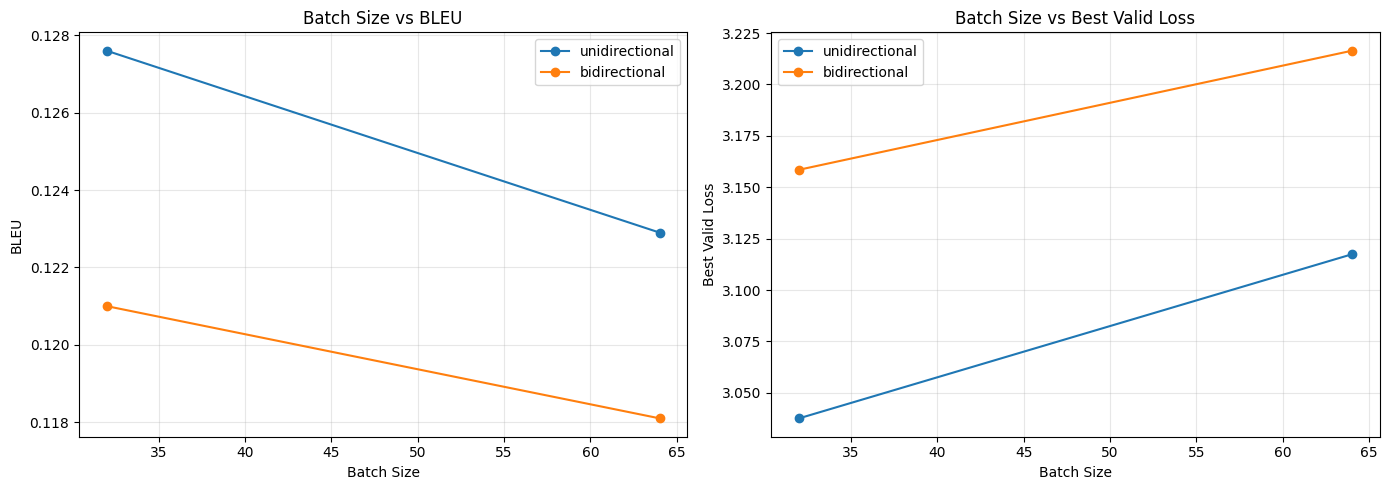

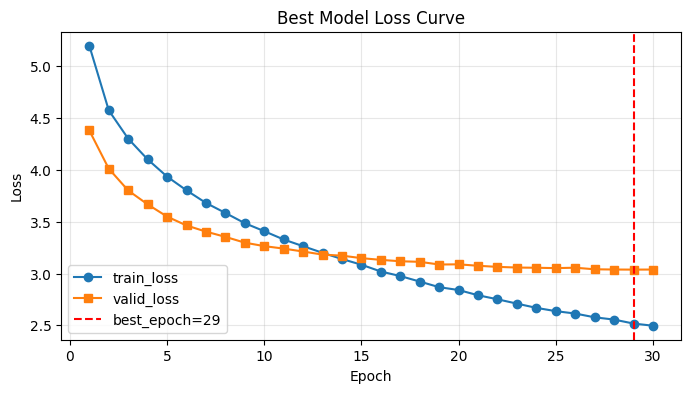

In [30]:
import matplotlib.pyplot as plt

success_df = experiment_results_df[experiment_results_df["status"] == "success"].copy()

if len(success_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for direction in success_df["encoder_direction"].unique():
        subset = success_df[success_df["encoder_direction"] == direction].sort_values("batch_size")

        axes[0].plot(
            subset["batch_size"],
            subset["bleu_score"],
            marker="o",
            label=direction,
        )

        axes[1].plot(
            subset["batch_size"],
            subset["best_valid_loss"],
            marker="o",
            label=direction,
        )

    axes[0].set_title("Batch Size vs BLEU")
    axes[0].set_xlabel("Batch Size")
    axes[0].set_ylabel("BLEU")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].set_title("Batch Size vs Best Valid Loss")
    axes[1].set_xlabel("Batch Size")
    axes[1].set_ylabel("Best Valid Loss")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(best_history_df["epoch"], best_history_df["train_loss"], marker="o", label="train_loss")
    plt.plot(best_history_df["epoch"], best_history_df["valid_loss"], marker="s", label="valid_loss")
    plt.axvline(best_overall["config"]["best_epoch"], color="red", linestyle="--", label=f"best_epoch={best_overall['config']['best_epoch']}")
    plt.title("Best Model Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("No successful experiment.")


### 최종 모델 추론

In [31]:
print("[Best Model Config]")
display(best_config_df)

evaluateRandomly_final(encoder_best, decoder_best, pairs_valid_final, n=10)


[Best Model Config]


,run_key,encoder_direction,batch_size,best_epoch,best_valid_loss,final_train_loss,final_valid_loss,bleu_score,num_epochs_ran,teacher_forcing_ratio,elapsed_sec,status
0,unidirectional_bs32,unidirectional,32,29,3.0376,2.4967,3.0384,0.1276,30,0.7,809.85,success


> 캠핑이나 차박 등 야외에서 푹신한 잠자리를 느낄 수 있습니다.
= You can feel a soft bed outdoors, such as camping or car camping.
< You can feel free to the table or tableware or tableware.
subword: ['SOS', '▁You', '▁can', '▁feel', '▁free', '▁to', '▁the', '▁table', '▁or', '▁table', 'ware', '▁or', '▁table', 'ware', '.']

> 그 옆에 있는 것은 탕평채라고 합니다.
= The one next to it is called Tangpyeongchae.
< You said that you said he's called Jjatang.
subword: ['SOS', '▁You', '▁said', '▁that', '▁you', '▁said', '▁he', "'", 's', '▁called', '▁J', 'j', 'atang', '.']

> 제 이름은 AAA1이고, BBB에서 마케팅 업무를 담당하고 있습니다.
= My name is AAA1 and I am in charge of marketing at BBB.
< My name is AAA, I am in charge of BBB in marketing.
subword: ['SOS', '▁My', '▁name', '▁is', '▁AAA', ',', '▁I', '▁am', '▁in', '▁charge', '▁of', '▁BBB', '▁in', '▁marketing', '.']

> 우리는 머리 받침이 있고 그 위에 누웠다.
= We had headrests and laid down on it.
< We have the hands, and the the imagination.
subword: ['SOS', '▁We', '▁have', '▁the', '▁hands', ',', '▁and', '▁the', '▁the', '

### 최종모델 BLEU & BERTScore


In [32]:
bleu_score_best = calculate_bleu_score_final(
    encoder_best,
    decoder_best,
    pairs_valid_final,
    input_lang_final,
    output_lang_final,
)

# If this is slow, change pairs_valid_final to pairs_valid_final[:200] for a quick check.
bertscore_pairs = pairs_valid_final
bertscore_df, bertscore_summary = calculate_bertscore_final(
    encoder_best,
    decoder_best,
    bertscore_pairs,
    input_lang_final,
    output_lang_final,
    lang="en",
)

final_metric_summary_df = pd.DataFrame([{
    "encoder_direction": best_overall["config"]["encoder_direction"],
    "batch_size": best_overall["config"]["batch_size"],
    "best_epoch": best_overall["config"]["best_epoch"],
    "best_valid_loss": best_overall["config"]["best_valid_loss"],
    "BLEU": round(float(bleu_score_best), 4),
    "BERTScore_P": bertscore_summary["bert_precision_mean"],
    "BERTScore_R": bertscore_summary["bert_recall_mean"],
    "BERTScore_F1": bertscore_summary["bert_f1_mean"],
}])

display(final_metric_summary_df)
display(bertscore_df.head(10))


Calculating BLEU for 996 pairs...
Average BLEU Score: 0.1276
Calculating BERTScore for 996 pairs...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

computing greedy matching.


  0%|          | 0/16 [00:00<?, ?it/s]

done in 3.75 seconds, 265.86 sentences/sec
Average BERTScore Precision: 0.8998
Average BERTScore Recall:    0.8993
Average BERTScore F1:        0.8995


,encoder_direction,batch_size,best_epoch,best_valid_loss,BLEU,BERTScore_P,BERTScore_R,BERTScore_F1
0,unidirectional,32,29,3.0376,0.1276,0.8998,0.8993,0.8995


,reference,candidate,bert_precision,bert_recall,bert_f1
0,"Oh, really?","Oh, really?",1.000000,1.000000,1.000000
1,I think Mino will do it.,I think I'm going to.,0.932355,0.917262,0.924747
2,So looking at this and keeping up with the dem...,So I'll be the to this time to be the the needs.,0.857225,0.877318,0.867155
3,You can feel the rich texture of your mouth wi...,It can be easily enjoy soft texture with soft ...,0.848535,0.874917,0.861525
4,Good afternoon.,Hello.,0.949922,0.923287,0.936415
5,How much fever do you think I had?,I'm been how I was I I was.,0.856577,0.840766,0.848598
6,Thank you for purchasing our kimchi refrigerator.,"Thank you for purchasing kimchi, I'm purchasin...",0.922608,0.931529,0.927047
7,Now our company is showing some business perfo...,"Now, our company's been working with our company.",0.918195,0.894378,0.906130
8,"Come to the windmill lounge, the landmark of FFF!",It's a famous Italian famous Italian Pyeongelu...,0.819862,0.852865,0.836038
9,In the car?,In the car?,1.000000,1.000000,1.000000


## 정리



### 1. EDA에서 확인한 문제

데이터 자체는 결측값이나 깨진 문자가 거의 없어서 전반적으로 깨끗한 편이었다.  
다만 다음과 같은 문제를 확인할 수 있었다.

- train 데이터에 약 2,300개 정도의 **중복 문장쌍 존재**
- 짧은 대화체 문장이 반복되어 **데이터 편향 가능성**
- 일부 긴 문장으로 인해 **최대 길이가 과도하게 커짐**
- 단어/형태소 토크나이저 사용 시 **vocab 크기 증가 및 OOV 발생**
- 문장 앞 `>` 같은 **불필요한 표기 노이즈 존재**

---

### 2. 전처리

EDA 결과를 바탕으로 다음과 같은 전처리를 진행했다.

- 중복 문장 제거 → 데이터 다양성 확보
- 유니코드/공백 정규화 → 동일 문장 통일
- `>` 마커 제거 → 불필요한 패턴 제거
- SentencePiece 사용 → OOV 감소 및 안정적인 토큰화
- 길이 재설정(95% 기준) → padding 낭비 감소

---

### 3. 모델 설계

**GRU 기반 Seq2Seq + Attention 구조**

- 단방향/양방향 encoder 비교 → 구조에 따른 성능 차이 확인

dropout, teacher forcing, early stopping 등을 적용 

---

### 4. 실험 결과

총 4가지 조합(양방향, 단방향, batch size 32, batch size 64)을 비교한 결과,

👉 **단방향 encoder + batch size 32**가 가장 좋은 성능을 보였다.

- BLEU: 0.1276  
- BERTScore F1: 0.8995  

이번 실험에서는 복잡한 양방향 모델보다  
**단순한 단방향 모델이 더 안정적으로 학습된 결과**가 나왔다.

---

### 5. 성능 평가

- BLEU는 낮음
- BERTScore는 높음 → 문맥을 어느정도 파악하고 있음

실제 결과를 보면
- 짧은 문장은 비교적 잘 번역함
- 긴 문장이나 복잡한 구조에서는 오류나 반복 발생